In [1]:
import matplotlib.pyplot as plt
from typing import List
import glob
import os
import numpy as np
import pandas as pd

In [2]:
NUMBER_OF_FLOWS = 50

STEPS = 5
INTERVAL_LENGTH = int(NUMBER_OF_FLOWS / STEPS)

In [3]:
def acceptance_rate(df, index_array: List, begin, sfc_type) -> List:
    if len(index_array) == 0:
        return []
    if index_array[-1][1] != "sfc_unique_p4_" + str(NUMBER_OF_FLOWS) and index_array[-1][
        1
    ] != "sfc_mono_p4_" + str(NUMBER_OF_FLOWS):
        return []
    acc_rate_array = []
    previous_index = 0
    copy_array_indexes = index_array.copy()
    copy_array_indexes.insert(0, begin)
    for i in range(INTERVAL_LENGTH):
        succ_array = df.iloc[
            copy_array_indexes[0][0] : copy_array_indexes[
                previous_index + round(len(copy_array_indexes) / INTERVAL_LENGTH)
            ][0]
            + 1
        ]["success"].values
        previous_index = previous_index + round(len(copy_array_indexes) / INTERVAL_LENGTH)
        arr_data, counts = np.unique(succ_array, return_counts=True)
        if len(counts) == 1:
            if arr_data[0] == 0:
                acc_rate = 0
            elif arr_data[0] == 1:
                acc_rate = 1
        else:
            try:
                count_succ = counts[1]
                count_fail = counts[0]
                acc_rate = count_succ / (count_succ + count_fail)
            except:
                return []
        acc_rate_array.append(acc_rate)
    return acc_rate_array

In [4]:
def resource_utilization(resource_consumption: pd.Series, index_array, sfc_type):
    if len(index_array) == 0:
        return []
    if index_array[-1][1] != "sfc_unique_p4_" + str(NUMBER_OF_FLOWS) and index_array[-1][
        1
    ] != "sfc_mono_p4_" + str(NUMBER_OF_FLOWS):
        return []
    resource_utilization_arr = []
    previous_index = 0
    copy_array_indexes = index_array.copy()
    copy_array_indexes.insert(0, (0, 0))
    for i in range(INTERVAL_LENGTH):
        value = resource_consumption.iloc[
            copy_array_indexes[previous_index][0] : copy_array_indexes[
                previous_index + round(len(copy_array_indexes) / INTERVAL_LENGTH)
            ][0]
            + 1
        ].values
        # print(copy_array_indexes[previous_index]0)
        # print(len(value))
        # print(copy_array_indexes[previous_index + round(len(copy_array_indexes) / INTERVAL_LENGTH)])
        previous_index = previous_index + round(len(copy_array_indexes) / INTERVAL_LENGTH)
        average_consumption = np.mean(value)
        resource_utilization_arr.append(average_consumption)
    return resource_utilization_arr

In [5]:
def flow_delimiter(df: pd.DataFrame, n_flows: int) -> List:
    """calculate where each flow ends.
    Returns:
        List of tuples in the form (index, sfc_id)
    Args:
        df (pd.DataFrame): dataframe for a specific file
    """
    memo = []
    list_ocurrences_ends = []
    list_ocurrences_begin = 0
    for count in range(1, n_flows + 1):
        for i, data in df.iterrows():
            sfc_id = data["sfc_id"]
            if sfc_id not in memo:
                if (
                    sfc_id == "sfc_cache_p1_1"
                    and list_ocurrences_begin == 0
                    or sfc_id == "sfc_mono_p1_1"
                    and list_ocurrences_begin == 0
                ):
                    list_ocurrences_begin = (i, sfc_id)
                if sfc_id == "sfc_unique_p4_{count}".format(
                    count=count
                ) or sfc_id == "sfc_mono_p4_{count}".format(count=count):
                    list_ocurrences_ends.append((i, sfc_id))
                    memo.append(sfc_id)
    return (list_ocurrences_ends, list_ocurrences_begin)

In [6]:
results_flows_directories = glob.glob("../results_flows_*")

In [7]:
from fnmatch import fnmatch

df = pd.DataFrame()
df_resource = pd.DataFrame()
for result_flows in results_flows_directories:
    results_algorithms = os.listdir(result_flows)
    for result_algorithms in results_algorithms:
        if fnmatch(result_algorithms, "*_sfc_off_*"):
            sfc_type = "off"
        else:
            sfc_type = "on"
        path_algorithms = str(result_flows) + "/" + result_algorithms
        for i, file in enumerate(os.listdir(path_algorithms)):
            try:
                df_file = pd.read_csv(path_algorithms + "/" + file)
                df_file["prob"] = str(result_algorithms).split("_")[5]
                df_file["algorithm"] = str(result_algorithms).split("_")[0]
                df_file["n_execution"] = i
                df_file["sfc"] = sfc_type
                sfc_list_id = pd.unique(df_file["sfc_id"])
                new_df = pd.DataFrame()
                for sfc_id in sfc_list_id:
                    ocurrences = df_file[df_file["sfc_id"] == sfc_id]
                    index_to_keep = pd.Index(ocurrences.iloc[-1])[0]
                    new_df = pd.concat(
                        [new_df, df_file.iloc[index_to_keep - 1 : index_to_keep, :]],
                        ignore_index=True,
                    )
                df = pd.concat([df, new_df], ignore_index=True)

                # df = pd.concat([df, df_file], ignore_index=True)
            except:
                continue

In [8]:
df.loc[:, "latency"] = df.loc[:, "latency"].replace("None", -1)

In [9]:
df.loc[:, "latency"] = df.loc[:, "latency"].astype(float)

In [10]:
algorithms = df["algorithm"].values
executions = np.arange(df["n_execution"].max())
probabilities = df["prob"].unique()

In [11]:
indexes_array_sfc_off = {
    "dp": {"0.0": [], "0.1": [], "0.2": [], "0.3": [], "0.4": [], "0.5": []},
    "musfico": {"0.0": [], "0.1": [], "0.2": [], "0.3": [], "0.4": [], "0.5": []},
    "k": {"0.0": [], "0.1": [], "0.2": [], "0.3": [], "0.4": [], "0.5": []},
    "g": {"0.0": [], "0.1": [], "0.2": [], "0.3": [], "0.4": [], "0.5": []},
}
indexes_array_sfc_off_executions = {
    "dp": {"0.0": [], "0.1": [], "0.2": [], "0.3": [], "0.4": [], "0.5": []},
    "musfico": {"0.0": [], "0.1": [], "0.2": [], "0.3": [], "0.4": [], "0.5": []},
    "k": {"0.0": [], "0.1": [], "0.2": [], "0.3": [], "0.4": [], "0.5": []},
    "g": {"0.0": [], "0.1": [], "0.2": [], "0.3": [], "0.4": [], "0.5": []},
}
indexes_array_sfc_on = {
    "dp": {"0.0": [], "0.1": [], "0.2": [], "0.3": [], "0.4": [], "0.5": []},
    "musfico": {"0.0": [], "0.1": [], "0.2": [], "0.3": [], "0.4": [], "0.5": []},
    "k": {"0.0": [], "0.1": [], "0.2": [], "0.3": [], "0.4": [], "0.5": []},
    "g": {"0.0": [], "0.1": [], "0.2": [], "0.3": [], "0.4": [], "0.5": []},
}
indexes_array_sfc_on_executions = {
    "dp": {"0.0": [], "0.1": [], "0.2": [], "0.3": [], "0.4": [], "0.5": []},
    "musfico": {"0.0": [], "0.1": [], "0.2": [], "0.3": [], "0.4": [], "0.5": []},
    "k": {"0.0": [], "0.1": [], "0.2": [], "0.3": [], "0.4": [], "0.5": []},
    "g": {"0.0": [], "0.1": [], "0.2": [], "0.3": [], "0.4": [], "0.5": []},
}

In [12]:
indexes_array_sfc_off_resource = {
    "dp": {"0.0": [], "0.1": [], "0.2": [], "0.3": [], "0.4": [], "0.5": []},
    "musfico": {"0.0": [], "0.1": [], "0.2": [], "0.3": [], "0.4": [], "0.5": []},
    "k": {"0.0": [], "0.1": [], "0.2": [], "0.3": [], "0.4": [], "0.5": []},
    "g": {"0.0": [], "0.1": [], "0.2": [], "0.3": [], "0.4": [], "0.5": []},
}
indexes_array_sfc_off_executions_resource = {
    "dp": {"0.0": [], "0.1": [], "0.2": [], "0.3": [], "0.4": [], "0.5": []},
    "musfico": {"0.0": [], "0.1": [], "0.2": [], "0.3": [], "0.4": [], "0.5": []},
    "k": {"0.0": [], "0.1": [], "0.2": [], "0.3": [], "0.4": [], "0.5": []},
    "g": {"0.0": [], "0.1": [], "0.2": [], "0.3": [], "0.4": [], "0.5": []},
}
indexes_array_sfc_on_resource = {
    "dp": {"0.0": [], "0.1": [], "0.2": [], "0.3": [], "0.4": [], "0.5": []},
    "musfico": {"0.0": [], "0.1": [], "0.2": [], "0.3": [], "0.4": [], "0.5": []},
    "k": {"0.0": [], "0.1": [], "0.2": [], "0.3": [], "0.4": [], "0.5": []},
    "g": {"0.0": [], "0.1": [], "0.2": [], "0.3": [], "0.4": [], "0.5": []},
}
indexes_array_sfc_on_executions_resource = {
    "dp": {"0.0": [], "0.1": [], "0.2": [], "0.3": [], "0.4": [], "0.5": []},
    "musfico": {"0.0": [], "0.1": [], "0.2": [], "0.3": [], "0.4": [], "0.5": []},
    "k": {"0.0": [], "0.1": [], "0.2": [], "0.3": [], "0.4": [], "0.5": []},
    "g": {"0.0": [], "0.1": [], "0.2": [], "0.3": [], "0.4": [], "0.5": []},
}

In [13]:
for exec in executions:
    ocurrence_sfc_off_dp_0 = df[
        (df["algorithm"] == "dp")
        & (df["n_execution"] == exec)
        & (df["prob"] == "0.0")
        & (df["sfc"] == "off")
    ].reset_index()
    ocurrence_sfc_off_dpnew_0 = df[
        (df["algorithm"] == "musfico")
        & (df["n_execution"] == exec)
        & (df["prob"] == "0.0")
        & (df["sfc"] == "off")
    ].reset_index()
    ocurrence_sfc_off_k_0 = df[
        (df["algorithm"] == "k")
        & (df["n_execution"] == exec)
        & (df["prob"] == "0.0")
        & (df["sfc"] == "off")
    ].reset_index()
    ocurrence_sfc_off_g_0 = df[
        (df["algorithm"] == "g")
        & (df["n_execution"] == exec)
        & (df["prob"] == "0.0")
        & (df["sfc"] == "off")
    ].reset_index()

    ocurrence_sfc_off_dp_10 = df[
        (df["algorithm"] == "dp")
        & (df["n_execution"] == exec)
        & (df["prob"] == "0.1")
        & (df["sfc"] == "off")
    ].reset_index()
    ocurrence_sfc_off_dpnew_10 = df[
        (df["algorithm"] == "musfico")
        & (df["n_execution"] == exec)
        & (df["prob"] == "0.1")
        & (df["sfc"] == "off")
    ].reset_index()
    ocurrence_sfc_off_k_10 = df[
        (df["algorithm"] == "k")
        & (df["n_execution"] == exec)
        & (df["prob"] == "0.1")
        & (df["sfc"] == "off")
    ].reset_index()
    ocurrence_sfc_off_g_10 = df[
        (df["algorithm"] == "g")
        & (df["n_execution"] == exec)
        & (df["prob"] == "0.1")
        & (df["sfc"] == "off")
    ].reset_index()

    ocurrence_sfc_off_dp_20 = df[
        (df["algorithm"] == "dp")
        & (df["n_execution"] == exec)
        & (df["prob"] == "0.2")
        & (df["sfc"] == "off")
    ].reset_index()
    ocurrence_sfc_off_dpnew_20 = df[
        (df["algorithm"] == "musfico")
        & (df["n_execution"] == exec)
        & (df["prob"] == "0.2")
        & (df["sfc"] == "off")
    ].reset_index()
    ocurrence_sfc_off_k_20 = df[
        (df["algorithm"] == "k")
        & (df["n_execution"] == exec)
        & (df["prob"] == "0.2")
        & (df["sfc"] == "off")
    ].reset_index()
    ocurrence_sfc_off_g_20 = df[
        (df["algorithm"] == "g")
        & (df["n_execution"] == exec)
        & (df["prob"] == "0.2")
        & (df["sfc"] == "off")
    ].reset_index()

    ocurrence_sfc_off_dp_30 = df[
        (df["algorithm"] == "dp")
        & (df["n_execution"] == exec)
        & (df["prob"] == "0.3")
        & (df["sfc"] == "off")
    ].reset_index()
    ocurrence_sfc_off_dpnew_30 = df[
        (df["algorithm"] == "musfico")
        & (df["n_execution"] == exec)
        & (df["prob"] == "0.3")
        & (df["sfc"] == "off")
    ].reset_index()
    ocurrence_sfc_off_k_30 = df[
        (df["algorithm"] == "k")
        & (df["n_execution"] == exec)
        & (df["prob"] == "0.3")
        & (df["sfc"] == "off")
    ].reset_index()
    ocurrence_sfc_off_g_30 = df[
        (df["algorithm"] == "g")
        & (df["n_execution"] == exec)
        & (df["prob"] == "0.3")
        & (df["sfc"] == "off")
    ].reset_index()

    ocurrence_sfc_off_dp_40 = df[
        (df["algorithm"] == "dp")
        & (df["n_execution"] == exec)
        & (df["prob"] == "0.4")
        & (df["sfc"] == "off")
    ].reset_index()
    ocurrence_sfc_off_dpnew_40 = df[
        (df["algorithm"] == "musfico")
        & (df["n_execution"] == exec)
        & (df["prob"] == "0.4")
        & (df["sfc"] == "off")
    ].reset_index()
    ocurrence_sfc_off_k_40 = df[
        (df["algorithm"] == "k")
        & (df["n_execution"] == exec)
        & (df["prob"] == "0.4")
        & (df["sfc"] == "off")
    ].reset_index()
    ocurrence_sfc_off_g_40 = df[
        (df["algorithm"] == "g")
        & (df["n_execution"] == exec)
        & (df["prob"] == "0.4")
        & (df["sfc"] == "off")
    ].reset_index()

    ocurrence_sfc_off_dp_50 = df[
        (df["algorithm"] == "dp")
        & (df["n_execution"] == exec)
        & (df["prob"] == "0.5")
        & (df["sfc"] == "off")
    ].reset_index()
    ocurrence_sfc_off_dpnew_50 = df[
        (df["algorithm"] == "musfico")
        & (df["n_execution"] == exec)
        & (df["prob"] == "0.5")
        & (df["sfc"] == "off")
    ].reset_index()
    ocurrence_sfc_off_k_50 = df[
        (df["algorithm"] == "k")
        & (df["n_execution"] == exec)
        & (df["prob"] == "0.5")
        & (df["sfc"] == "off")
    ].reset_index()
    ocurrence_sfc_off_g_50 = df[
        (df["algorithm"] == "g")
        & (df["n_execution"] == exec)
        & (df["prob"] == "0.5")
        & (df["sfc"] == "off")
    ].reset_index()

    ocurrence_sfc_on_dp_0 = df[
        (df["algorithm"] == "dp")
        & (df["n_execution"] == exec)
        & (df["prob"] == "0.0")
        & (df["sfc"] == "on")
    ].reset_index()
    ocurrence_sfc_on_dpnew_0 = df[
        (df["algorithm"] == "musfico")
        & (df["n_execution"] == exec)
        & (df["prob"] == "0.0")
        & (df["sfc"] == "on")
    ].reset_index()
    ocurrence_sfc_on_k_0 = df[
        (df["algorithm"] == "k")
        & (df["n_execution"] == exec)
        & (df["prob"] == "0.0")
        & (df["sfc"] == "on")
    ].reset_index()
    ocurrence_sfc_on_g_0 = df[
        (df["algorithm"] == "g")
        & (df["n_execution"] == exec)
        & (df["prob"] == "0.0")
        & (df["sfc"] == "on")
    ].reset_index()

    ocurrence_sfc_on_dp_10 = df[
        (df["algorithm"] == "dp")
        & (df["n_execution"] == exec)
        & (df["prob"] == "0.1")
        & (df["sfc"] == "on")
    ].reset_index()
    ocurrence_sfc_on_dpnew_10 = df[
        (df["algorithm"] == "musfico")
        & (df["n_execution"] == exec)
        & (df["prob"] == "0.1")
        & (df["sfc"] == "on")
    ].reset_index()
    ocurrence_sfc_on_k_10 = df[
        (df["algorithm"] == "k")
        & (df["n_execution"] == exec)
        & (df["prob"] == "0.1")
        & (df["sfc"] == "on")
    ].reset_index()
    ocurrence_sfc_on_g_10 = df[
        (df["algorithm"] == "g")
        & (df["n_execution"] == exec)
        & (df["prob"] == "0.1")
        & (df["sfc"] == "on")
    ].reset_index()

    ocurrence_sfc_on_dp_20 = df[
        (df["algorithm"] == "dp")
        & (df["n_execution"] == exec)
        & (df["prob"] == "0.2")
        & (df["sfc"] == "on")
    ].reset_index()
    ocurrence_sfc_on_dpnew_20 = df[
        (df["algorithm"] == "musfico")
        & (df["n_execution"] == exec)
        & (df["prob"] == "0.2")
        & (df["sfc"] == "on")
    ].reset_index()
    ocurrence_sfc_on_k_20 = df[
        (df["algorithm"] == "k")
        & (df["n_execution"] == exec)
        & (df["prob"] == "0.2")
        & (df["sfc"] == "on")
    ].reset_index()
    ocurrence_sfc_on_g_20 = df[
        (df["algorithm"] == "g")
        & (df["n_execution"] == exec)
        & (df["prob"] == "0.2")
        & (df["sfc"] == "on")
    ].reset_index()

    ocurrence_sfc_on_dp_30 = df[
        (df["algorithm"] == "dp")
        & (df["n_execution"] == exec)
        & (df["prob"] == "0.3")
        & (df["sfc"] == "on")
    ].reset_index()
    ocurrence_sfc_on_dpnew_30 = df[
        (df["algorithm"] == "musfico")
        & (df["n_execution"] == exec)
        & (df["prob"] == "0.3")
        & (df["sfc"] == "on")
    ].reset_index()
    ocurrence_sfc_on_k_30 = df[
        (df["algorithm"] == "k")
        & (df["n_execution"] == exec)
        & (df["prob"] == "0.3")
        & (df["sfc"] == "on")
    ].reset_index()
    ocurrence_sfc_on_g_30 = df[
        (df["algorithm"] == "g")
        & (df["n_execution"] == exec)
        & (df["prob"] == "0.3")
        & (df["sfc"] == "on")
    ].reset_index()

    ocurrence_sfc_on_dp_40 = df[
        (df["algorithm"] == "dp")
        & (df["n_execution"] == exec)
        & (df["prob"] == "0.4")
        & (df["sfc"] == "on")
    ].reset_index()
    ocurrence_sfc_on_dpnew_40 = df[
        (df["algorithm"] == "musfico")
        & (df["n_execution"] == exec)
        & (df["prob"] == "0.4")
        & (df["sfc"] == "on")
    ].reset_index()
    ocurrence_sfc_on_k_40 = df[
        (df["algorithm"] == "k")
        & (df["n_execution"] == exec)
        & (df["prob"] == "0.4")
        & (df["sfc"] == "on")
    ].reset_index()
    ocurrence_sfc_on_g_40 = df[
        (df["algorithm"] == "g")
        & (df["n_execution"] == exec)
        & (df["prob"] == "0.4")
        & (df["sfc"] == "on")
    ].reset_index()

    ocurrence_sfc_on_dp_50 = df[
        (df["algorithm"] == "dp")
        & (df["n_execution"] == exec)
        & (df["prob"] == "0.5")
        & (df["sfc"] == "on")
    ].reset_index()
    ocurrence_sfc_on_dpnew_50 = df[
        (df["algorithm"] == "musfico")
        & (df["n_execution"] == exec)
        & (df["prob"] == "0.5")
        & (df["sfc"] == "on")
    ].reset_index()
    ocurrence_sfc_on_k_50 = df[
        (df["algorithm"] == "k")
        & (df["n_execution"] == exec)
        & (df["prob"] == "0.5")
        & (df["sfc"] == "on")
    ].reset_index()
    ocurrence_sfc_on_g_50 = df[
        (df["algorithm"] == "g")
        & (df["n_execution"] == exec)
        & (df["prob"] == "0.5")
        & (df["sfc"] == "on")
    ].reset_index()

    if len(ocurrence_sfc_off_dp_0) != 0:
        indexes_array_sfc_off["dp"]["0.0"].append(
            flow_delimiter(ocurrence_sfc_off_dp_0, n_flows=NUMBER_OF_FLOWS)
        )
        indexes_array_sfc_off_executions["dp"]["0.0"].append(exec)
    if len(ocurrence_sfc_off_dp_10) != 0:
        indexes_array_sfc_off["dp"]["0.1"].append(
            flow_delimiter(ocurrence_sfc_off_dp_10, n_flows=NUMBER_OF_FLOWS)
        )
        indexes_array_sfc_off_executions["dp"]["0.1"].append(exec)
    if len(ocurrence_sfc_off_dp_20) != 0:
        indexes_array_sfc_off["dp"]["0.2"].append(
            flow_delimiter(ocurrence_sfc_off_dp_20, n_flows=NUMBER_OF_FLOWS)
        )
        indexes_array_sfc_off_executions["dp"]["0.2"].append(exec)
    if len(ocurrence_sfc_off_dp_30) != 0:
        indexes_array_sfc_off["dp"]["0.3"].append(
            flow_delimiter(ocurrence_sfc_off_dp_30, n_flows=NUMBER_OF_FLOWS)
        )
        indexes_array_sfc_off_executions["dp"]["0.3"].append(exec)
    if len(ocurrence_sfc_off_dp_40) != 0:
        indexes_array_sfc_off["dp"]["0.4"].append(
            flow_delimiter(ocurrence_sfc_off_dp_40, n_flows=NUMBER_OF_FLOWS)
        )
        indexes_array_sfc_off_executions["dp"]["0.4"].append(exec)
    if len(ocurrence_sfc_off_dp_50) != 0:
        indexes_array_sfc_off["dp"]["0.5"].append(
            flow_delimiter(ocurrence_sfc_off_dp_50, n_flows=NUMBER_OF_FLOWS)
        )
        indexes_array_sfc_off_executions["dp"]["0.5"].append(exec)

    if len(ocurrence_sfc_off_dpnew_0) != 0:
        indexes_array_sfc_off["musfico"]["0.0"].append(
            flow_delimiter(ocurrence_sfc_off_dpnew_0, n_flows=NUMBER_OF_FLOWS)
        )
        indexes_array_sfc_off_executions["musfico"]["0.0"].append(exec)
    if len(ocurrence_sfc_off_dpnew_10) != 0:
        indexes_array_sfc_off["musfico"]["0.1"].append(
            flow_delimiter(ocurrence_sfc_off_dpnew_10, n_flows=NUMBER_OF_FLOWS)
        )
        indexes_array_sfc_off_executions["musfico"]["0.1"].append(exec)
    if len(ocurrence_sfc_off_dpnew_20) != 0:
        indexes_array_sfc_off["musfico"]["0.2"].append(
            flow_delimiter(ocurrence_sfc_off_dpnew_20, n_flows=NUMBER_OF_FLOWS)
        )
        indexes_array_sfc_off_executions["musfico"]["0.2"].append(exec)
    if len(ocurrence_sfc_off_dpnew_30) != 0:
        indexes_array_sfc_off["musfico"]["0.3"].append(
            flow_delimiter(ocurrence_sfc_off_dpnew_30, n_flows=NUMBER_OF_FLOWS)
        )
        indexes_array_sfc_off_executions["musfico"]["0.3"].append(exec)
    if len(ocurrence_sfc_off_dpnew_40) != 0:
        indexes_array_sfc_off["musfico"]["0.4"].append(
            flow_delimiter(ocurrence_sfc_off_dpnew_40, n_flows=NUMBER_OF_FLOWS)
        )
        indexes_array_sfc_off_executions["musfico"]["0.4"].append(exec)
    if len(ocurrence_sfc_off_dpnew_50) != 0:
        indexes_array_sfc_off["musfico"]["0.5"].append(
            flow_delimiter(ocurrence_sfc_off_dpnew_50, n_flows=NUMBER_OF_FLOWS)
        )
        indexes_array_sfc_off_executions["musfico"]["0.5"].append(exec)

    if len(ocurrence_sfc_off_k_0) != 0:
        indexes_array_sfc_off["k"]["0.0"].append(
            flow_delimiter(ocurrence_sfc_off_k_0, n_flows=NUMBER_OF_FLOWS)
        )
        indexes_array_sfc_off_executions["k"]["0.0"].append(exec)
    if len(ocurrence_sfc_off_k_10) != 0:
        indexes_array_sfc_off["k"]["0.1"].append(
            flow_delimiter(ocurrence_sfc_off_k_10, n_flows=NUMBER_OF_FLOWS)
        )
        indexes_array_sfc_off_executions["k"]["0.1"].append(exec)
    if len(ocurrence_sfc_off_k_20) != 0:
        indexes_array_sfc_off["k"]["0.2"].append(
            flow_delimiter(ocurrence_sfc_off_k_20, n_flows=NUMBER_OF_FLOWS)
        )
        indexes_array_sfc_off_executions["k"]["0.2"].append(exec)
    if len(ocurrence_sfc_off_k_30) != 0:
        indexes_array_sfc_off["k"]["0.3"].append(
            flow_delimiter(ocurrence_sfc_off_k_30, n_flows=NUMBER_OF_FLOWS)
        )
        indexes_array_sfc_off_executions["k"]["0.3"].append(exec)
    if len(ocurrence_sfc_off_k_40) != 0:
        indexes_array_sfc_off["k"]["0.4"].append(
            flow_delimiter(ocurrence_sfc_off_k_40, n_flows=NUMBER_OF_FLOWS)
        )
        indexes_array_sfc_off_executions["k"]["0.4"].append(exec)
    if len(ocurrence_sfc_off_k_50) != 0:
        indexes_array_sfc_off["k"]["0.5"].append(
            flow_delimiter(ocurrence_sfc_off_k_50, n_flows=NUMBER_OF_FLOWS)
        )
        indexes_array_sfc_off_executions["k"]["0.5"].append(exec)

    if len(ocurrence_sfc_off_g_0) != 0:
        indexes_array_sfc_off["g"]["0.0"].append(
            flow_delimiter(ocurrence_sfc_off_g_0, n_flows=NUMBER_OF_FLOWS)
        )
        indexes_array_sfc_off_executions["g"]["0.0"].append(exec)
    if len(ocurrence_sfc_off_k_10) != 0:
        indexes_array_sfc_off["g"]["0.1"].append(
            flow_delimiter(ocurrence_sfc_off_g_10, n_flows=NUMBER_OF_FLOWS)
        )
        indexes_array_sfc_off_executions["g"]["0.1"].append(exec)
    if len(ocurrence_sfc_off_g_20) != 0:
        indexes_array_sfc_off["g"]["0.2"].append(
            flow_delimiter(ocurrence_sfc_off_g_20, n_flows=NUMBER_OF_FLOWS)
        )
        indexes_array_sfc_off_executions["g"]["0.2"].append(exec)
    if len(ocurrence_sfc_off_g_30) != 0:
        indexes_array_sfc_off["g"]["0.3"].append(
            flow_delimiter(ocurrence_sfc_off_g_30, n_flows=NUMBER_OF_FLOWS)
        )
        indexes_array_sfc_off_executions["g"]["0.3"].append(exec)
    if len(ocurrence_sfc_off_g_40) != 0:
        indexes_array_sfc_off["g"]["0.4"].append(
            flow_delimiter(ocurrence_sfc_off_g_40, n_flows=NUMBER_OF_FLOWS)
        )
        indexes_array_sfc_off_executions["g"]["0.4"].append(exec)
    if len(ocurrence_sfc_off_g_50) != 0:
        indexes_array_sfc_off["g"]["0.5"].append(
            flow_delimiter(ocurrence_sfc_off_g_50, n_flows=NUMBER_OF_FLOWS)
        )
        indexes_array_sfc_off_executions["g"]["0.5"].append(exec)

    if len(ocurrence_sfc_on_dp_0) != 0:
        indexes_array_sfc_on["dp"]["0.0"].append(
            flow_delimiter(ocurrence_sfc_on_dp_0, n_flows=NUMBER_OF_FLOWS)
        )
        indexes_array_sfc_on_executions["dp"]["0.0"].append(exec)
    if len(ocurrence_sfc_on_dp_10) != 0:
        indexes_array_sfc_on["dp"]["0.1"].append(
            flow_delimiter(ocurrence_sfc_on_dp_10, n_flows=NUMBER_OF_FLOWS)
        )
        indexes_array_sfc_on_executions["dp"]["0.1"].append(exec)
    if len(ocurrence_sfc_on_dp_20) != 0:
        indexes_array_sfc_on["dp"]["0.2"].append(
            flow_delimiter(ocurrence_sfc_on_dp_20, n_flows=NUMBER_OF_FLOWS)
        )
        indexes_array_sfc_on_executions["dp"]["0.2"].append(exec)
    if len(ocurrence_sfc_on_dp_30) != 0:
        indexes_array_sfc_on["dp"]["0.3"].append(
            flow_delimiter(ocurrence_sfc_on_dp_30, n_flows=NUMBER_OF_FLOWS)
        )
        indexes_array_sfc_on_executions["dp"]["0.3"].append(exec)
    if len(ocurrence_sfc_on_dp_40) != 0:
        indexes_array_sfc_on["dp"]["0.4"].append(
            flow_delimiter(ocurrence_sfc_on_dp_40, n_flows=NUMBER_OF_FLOWS)
        )
        indexes_array_sfc_on_executions["dp"]["0.4"].append(exec)
    if len(ocurrence_sfc_on_dp_50) != 0:
        indexes_array_sfc_on["dp"]["0.5"].append(
            flow_delimiter(ocurrence_sfc_on_dp_50, n_flows=NUMBER_OF_FLOWS)
        )
        indexes_array_sfc_on_executions["dp"]["0.5"].append(exec)
    if len(ocurrence_sfc_on_dpnew_0) != 0:
        indexes_array_sfc_on["musfico"]["0.0"].append(
            flow_delimiter(ocurrence_sfc_on_dpnew_0, n_flows=NUMBER_OF_FLOWS)
        )
        indexes_array_sfc_on_executions["musfico"]["0.0"].append(exec)
    if len(ocurrence_sfc_on_dpnew_10) != 0:
        indexes_array_sfc_on["musfico"]["0.1"].append(
            flow_delimiter(ocurrence_sfc_on_dpnew_10, n_flows=NUMBER_OF_FLOWS)
        )
        indexes_array_sfc_on_executions["musfico"]["0.1"].append(exec)
    if len(ocurrence_sfc_on_dpnew_20) != 0:
        indexes_array_sfc_on["musfico"]["0.2"].append(
            flow_delimiter(ocurrence_sfc_on_dpnew_20, n_flows=NUMBER_OF_FLOWS)
        )
        indexes_array_sfc_on_executions["musfico"]["0.2"].append(exec)
    if len(ocurrence_sfc_on_dpnew_30) != 0:
        indexes_array_sfc_on["musfico"]["0.3"].append(
            flow_delimiter(ocurrence_sfc_on_dpnew_30, n_flows=NUMBER_OF_FLOWS)
        )
        indexes_array_sfc_on_executions["musfico"]["0.3"].append(exec)
    if len(ocurrence_sfc_on_dpnew_40) != 0:
        indexes_array_sfc_on["musfico"]["0.4"].append(
            flow_delimiter(ocurrence_sfc_on_dpnew_40, n_flows=NUMBER_OF_FLOWS)
        )
        indexes_array_sfc_on_executions["musfico"]["0.4"].append(exec)
    if len(ocurrence_sfc_on_dpnew_50) != 0:
        indexes_array_sfc_on["musfico"]["0.5"].append(
            flow_delimiter(ocurrence_sfc_on_dpnew_50, n_flows=NUMBER_OF_FLOWS)
        )
        indexes_array_sfc_on_executions["musfico"]["0.5"].append(exec)

    if len(ocurrence_sfc_on_k_0) != 0:
        indexes_array_sfc_on["k"]["0.0"].append(
            flow_delimiter(ocurrence_sfc_on_k_0, n_flows=NUMBER_OF_FLOWS)
        )
        indexes_array_sfc_on_executions["k"]["0.0"].append(exec)
    if len(ocurrence_sfc_on_k_10) != 0:
        indexes_array_sfc_on["k"]["0.1"].append(
            flow_delimiter(ocurrence_sfc_on_k_10, n_flows=NUMBER_OF_FLOWS)
        )
        indexes_array_sfc_on_executions["k"]["0.1"].append(exec)
    if len(ocurrence_sfc_on_k_20) != 0:
        indexes_array_sfc_on["k"]["0.2"].append(
            flow_delimiter(ocurrence_sfc_on_k_20, n_flows=NUMBER_OF_FLOWS)
        )
        indexes_array_sfc_on_executions["k"]["0.2"].append(exec)
    if len(ocurrence_sfc_on_k_30) != 0:
        indexes_array_sfc_on["k"]["0.3"].append(
            flow_delimiter(ocurrence_sfc_on_k_30, n_flows=NUMBER_OF_FLOWS)
        )
        indexes_array_sfc_on_executions["k"]["0.3"].append(exec)
    if len(ocurrence_sfc_on_k_40) != 0:
        indexes_array_sfc_on["k"]["0.4"].append(
            flow_delimiter(ocurrence_sfc_on_k_40, n_flows=NUMBER_OF_FLOWS)
        )
        indexes_array_sfc_on_executions["k"]["0.4"].append(exec)
    if len(ocurrence_sfc_on_k_50) != 0:
        indexes_array_sfc_on["k"]["0.5"].append(
            flow_delimiter(ocurrence_sfc_on_k_50, n_flows=NUMBER_OF_FLOWS)
        )
        indexes_array_sfc_on_executions["k"]["0.5"].append(exec)

    if len(ocurrence_sfc_on_g_0) != 0:
        indexes_array_sfc_on["g"]["0.0"].append(
            flow_delimiter(ocurrence_sfc_on_g_0, n_flows=NUMBER_OF_FLOWS)
        )
        indexes_array_sfc_on_executions["g"]["0.0"].append(exec)
    if len(ocurrence_sfc_on_g_10) != 0:
        indexes_array_sfc_on["g"]["0.1"].append(
            flow_delimiter(ocurrence_sfc_on_g_10, n_flows=NUMBER_OF_FLOWS)
        )
        indexes_array_sfc_on_executions["g"]["0.1"].append(exec)
    if len(ocurrence_sfc_on_g_20) != 0:
        indexes_array_sfc_on["g"]["0.2"].append(
            flow_delimiter(ocurrence_sfc_on_g_20, n_flows=NUMBER_OF_FLOWS)
        )
        indexes_array_sfc_on_executions["g"]["0.2"].append(exec)
    if len(ocurrence_sfc_on_g_30) != 0:
        indexes_array_sfc_on["g"]["0.3"].append(
            flow_delimiter(ocurrence_sfc_on_g_30, n_flows=NUMBER_OF_FLOWS)
        )
        indexes_array_sfc_on_executions["g"]["0.3"].append(exec)
    if len(ocurrence_sfc_on_g_40) != 0:
        indexes_array_sfc_on["g"]["0.4"].append(
            flow_delimiter(ocurrence_sfc_on_g_40, n_flows=NUMBER_OF_FLOWS)
        )
        indexes_array_sfc_on_executions["g"]["0.4"].append(exec)
    if len(ocurrence_sfc_on_g_50) != 0:
        indexes_array_sfc_on["g"]["0.5"].append(
            flow_delimiter(ocurrence_sfc_on_g_50, n_flows=NUMBER_OF_FLOWS)
        )
        indexes_array_sfc_on_executions["g"]["0.5"].append(exec)

In [14]:
arr_dp_on_0 = [
    acceptance_rate(
        df[
            (df["algorithm"] == "dp")
            & (df["n_execution"] == indexes_array_sfc_on_executions["dp"]["0.0"][i])
            & (df["prob"] == "0.0")
            & (df["sfc"] == "on")
        ].reset_index(),
        arr[0],
        arr[1],
        sfc_type="on",
    )
    for i, arr in enumerate(indexes_array_sfc_on["dp"]["0.0"])
]

arr_dp_on_10 = [
    acceptance_rate(
        df[
            (df["algorithm"] == "dp")
            & (df["n_execution"] == indexes_array_sfc_on_executions["dp"]["0.1"][i])
            & (df["prob"] == "0.1")
            & (df["sfc"] == "on")
        ].reset_index(),
        arr[0],
        arr[1],
        sfc_type="on",
    )
    for i, arr in enumerate(indexes_array_sfc_on["dp"]["0.1"])
]

arr_dp_on_20 = [
    acceptance_rate(
        df[
            (df["algorithm"] == "dp")
            & (df["n_execution"] == indexes_array_sfc_on_executions["dp"]["0.2"][i])
            & (df["prob"] == "0.2")
            & (df["sfc"] == "on")
        ].reset_index(),
        arr[0],
        arr[1],
        sfc_type="on",
    )
    for i, arr in enumerate(indexes_array_sfc_on["dp"]["0.2"])
]

arr_dp_on_30 = [
    acceptance_rate(
        df[
            (df["algorithm"] == "dp")
            & (df["n_execution"] == indexes_array_sfc_on_executions["dp"]["0.3"][i])
            & (df["prob"] == "0.3")
            & (df["sfc"] == "on")
        ].reset_index(),
        arr[0],
        arr[1],
        sfc_type="on",
    )
    for i, arr in enumerate(indexes_array_sfc_on["dp"]["0.3"])
]

arr_dp_on_40 = [
    acceptance_rate(
        df[
            (df["algorithm"] == "dp")
            & (df["n_execution"] == indexes_array_sfc_on_executions["dp"]["0.4"][i])
            & (df["prob"] == "0.4")
            & (df["sfc"] == "on")
        ].reset_index(),
        arr[0],
        arr[1],
        sfc_type="on",
    )
    for i, arr in enumerate(indexes_array_sfc_on["dp"]["0.4"])
]

arr_dp_on_50 = [
    acceptance_rate(
        df[
            (df["algorithm"] == "dp")
            & (df["n_execution"] == indexes_array_sfc_on_executions["dp"]["0.5"][i])
            & (df["prob"] == "0.5")
            & (df["sfc"] == "on")
        ].reset_index(),
        arr[0],
        arr[1],
        sfc_type="on",
    )
    for i, arr in enumerate(indexes_array_sfc_on["dp"]["0.5"])
]

arr_dpnew_on_0 = [
    acceptance_rate(
        df[
            (df["algorithm"] == "musfico")
            & (df["n_execution"] == indexes_array_sfc_on_executions["musfico"]["0.0"][i])
            & (df["prob"] == "0.0")
            & (df["sfc"] == "on")
        ].reset_index(),
        arr[0],
        arr[1],
        sfc_type="on",
    )
    for i, arr in enumerate(indexes_array_sfc_on["musfico"]["0.0"])
]

arr_dpnew_on_10 = [
    acceptance_rate(
        df[
            (df["algorithm"] == "musfico")
            & (df["n_execution"] == indexes_array_sfc_on_executions["musfico"]["0.1"][i])
            & (df["prob"] == "0.1")
            & (df["sfc"] == "on")
        ].reset_index(),
        arr[0],
        arr[1],
        sfc_type="on",
    )
    for i, arr in enumerate(indexes_array_sfc_on["musfico"]["0.1"])
]

arr_dpnew_on_20 = [
    acceptance_rate(
        df[
            (df["algorithm"] == "musfico")
            & (df["n_execution"] == indexes_array_sfc_on_executions["musfico"]["0.2"][i])
            & (df["prob"] == "0.2")
            & (df["sfc"] == "on")
        ].reset_index(),
        arr[0],
        arr[1],
        sfc_type="on",
    )
    for i, arr in enumerate(indexes_array_sfc_on["musfico"]["0.2"])
]

arr_dpnew_on_30 = [
    acceptance_rate(
        df[
            (df["algorithm"] == "musfico")
            & (df["n_execution"] == indexes_array_sfc_on_executions["musfico"]["0.3"][i])
            & (df["prob"] == "0.3")
            & (df["sfc"] == "on")
        ].reset_index(),
        arr[0],
        arr[1],
        sfc_type="on",
    )
    for i, arr in enumerate(indexes_array_sfc_on["musfico"]["0.3"])
]

arr_dpnew_on_40 = [
    acceptance_rate(
        df[
            (df["algorithm"] == "musfico")
            & (df["n_execution"] == indexes_array_sfc_on_executions["musfico"]["0.4"][i])
            & (df["prob"] == "0.4")
            & (df["sfc"] == "on")
        ].reset_index(),
        arr[0],
        arr[1],
        sfc_type="on",
    )
    for i, arr in enumerate(indexes_array_sfc_on["musfico"]["0.4"])
]

arr_dpnew_on_50 = [
    acceptance_rate(
        df[
            (df["algorithm"] == "musfico")
            & (df["n_execution"] == indexes_array_sfc_on_executions["musfico"]["0.5"][i])
            & (df["prob"] == "0.5")
            & (df["sfc"] == "on")
        ].reset_index(),
        arr[0],
        arr[1],
        sfc_type="on",
    )
    for i, arr in enumerate(indexes_array_sfc_on["musfico"]["0.5"])
]

arr_k_on_0 = [
    acceptance_rate(
        df[
            (df["algorithm"] == "k")
            & (df["n_execution"] == indexes_array_sfc_on_executions["k"]["0.0"][i])
            & (df["prob"] == "0.0")
            & (df["sfc"] == "on")
        ].reset_index(),
        arr[0],
        arr[1],
        sfc_type="on",
    )
    for i, arr in enumerate(indexes_array_sfc_on["k"]["0.0"])
]

arr_k_on_10 = [
    acceptance_rate(
        df[
            (df["algorithm"] == "k")
            & (df["n_execution"] == indexes_array_sfc_on_executions["k"]["0.1"][i])
            & (df["prob"] == "0.1")
            & (df["sfc"] == "on")
        ].reset_index(),
        arr[0],
        arr[1],
        sfc_type="on",
    )
    for i, arr in enumerate(indexes_array_sfc_on["k"]["0.1"])
]

arr_k_on_20 = [
    acceptance_rate(
        df[
            (df["algorithm"] == "k")
            & (df["n_execution"] == indexes_array_sfc_on_executions["k"]["0.2"][i])
            & (df["prob"] == "0.2")
            & (df["sfc"] == "on")
        ].reset_index(),
        arr[0],
        arr[1],
        sfc_type="on",
    )
    for i, arr in enumerate(indexes_array_sfc_on["k"]["0.2"])
]

arr_k_on_30 = [
    acceptance_rate(
        df[
            (df["algorithm"] == "k")
            & (df["n_execution"] == indexes_array_sfc_on_executions["k"]["0.3"][i])
            & (df["prob"] == "0.3")
            & (df["sfc"] == "on")
        ].reset_index(),
        arr[0],
        arr[1],
        sfc_type="on",
    )
    for i, arr in enumerate(indexes_array_sfc_on["k"]["0.3"])
]

arr_k_on_40 = [
    acceptance_rate(
        df[
            (df["algorithm"] == "k")
            & (df["n_execution"] == indexes_array_sfc_on_executions["k"]["0.4"][i])
            & (df["prob"] == "0.4")
            & (df["sfc"] == "on")
        ].reset_index(),
        arr[0],
        arr[1],
        sfc_type="on",
    )
    for i, arr in enumerate(indexes_array_sfc_on["k"]["0.4"])
]

arr_k_on_50 = [
    acceptance_rate(
        df[
            (df["algorithm"] == "k")
            & (df["n_execution"] == indexes_array_sfc_on_executions["k"]["0.5"][i])
            & (df["prob"] == "0.5")
            & (df["sfc"] == "on")
        ].reset_index(),
        arr[0],
        arr[1],
        sfc_type="on",
    )
    for i, arr in enumerate(indexes_array_sfc_on["k"]["0.5"])
]

arr_g_on_0 = [
    acceptance_rate(
        df[
            (df["algorithm"] == "g")
            & (df["n_execution"] == indexes_array_sfc_on_executions["g"]["0.0"][i])
            & (df["prob"] == "0.0")
            & (df["sfc"] == "on")
        ].reset_index(),
        arr[0],
        arr[1],
        sfc_type="on",
    )
    for i, arr in enumerate(indexes_array_sfc_on["g"]["0.0"])
]

arr_g_on_10 = [
    acceptance_rate(
        df[
            (df["algorithm"] == "g")
            & (df["n_execution"] == indexes_array_sfc_on_executions["g"]["0.1"][i])
            & (df["prob"] == "0.1")
            & (df["sfc"] == "on")
        ].reset_index(),
        arr[0],
        arr[1],
        sfc_type="on",
    )
    for i, arr in enumerate(indexes_array_sfc_on["g"]["0.1"])
]

arr_g_on_20 = [
    acceptance_rate(
        df[
            (df["algorithm"] == "g")
            & (df["n_execution"] == indexes_array_sfc_on_executions["g"]["0.2"][i])
            & (df["prob"] == "0.2")
            & (df["sfc"] == "on")
        ].reset_index(),
        arr[0],
        arr[1],
        sfc_type="on",
    )
    for i, arr in enumerate(indexes_array_sfc_on["g"]["0.2"])
]

arr_g_on_30 = [
    acceptance_rate(
        df[
            (df["algorithm"] == "g")
            & (df["n_execution"] == indexes_array_sfc_on_executions["g"]["0.3"][i])
            & (df["prob"] == "0.3")
            & (df["sfc"] == "on")
        ].reset_index(),
        arr[0],
        arr[1],
        sfc_type="on",
    )
    for i, arr in enumerate(indexes_array_sfc_on["g"]["0.3"])
]

arr_g_on_40 = [
    acceptance_rate(
        df[
            (df["algorithm"] == "g")
            & (df["n_execution"] == indexes_array_sfc_on_executions["g"]["0.4"][i])
            & (df["prob"] == "0.4")
            & (df["sfc"] == "on")
        ].reset_index(),
        arr[0],
        arr[1],
        sfc_type="on",
    )
    for i, arr in enumerate(indexes_array_sfc_on["g"]["0.4"])
]

arr_g_on_50 = [
    acceptance_rate(
        df[
            (df["algorithm"] == "g")
            & (df["n_execution"] == indexes_array_sfc_on_executions["g"]["0.5"][i])
            & (df["prob"] == "0.5")
            & (df["sfc"] == "on")
        ].reset_index(),
        arr[0],
        arr[1],
        sfc_type="on",
    )
    for i, arr in enumerate(indexes_array_sfc_on["g"]["0.5"])
]

In [15]:
arr_dp_off_0 = [
    acceptance_rate(
        df[
            (df["algorithm"] == "dp")
            & (df["n_execution"] == indexes_array_sfc_off_executions["dp"]["0.0"][i])
            & (df["prob"] == "0.0")
            & (df["sfc"] == "off")
        ].reset_index(),
        arr[0],
        arr[1],
        sfc_type="off",
    )
    for i, arr in enumerate(indexes_array_sfc_off["dp"]["0.0"])
]

arr_dp_off_10 = [
    acceptance_rate(
        df[
            (df["algorithm"] == "dp")
            & (df["n_execution"] == indexes_array_sfc_off_executions["dp"]["0.1"][i])
            & (df["prob"] == "0.1")
            & (df["sfc"] == "off")
        ].reset_index(),
        arr[0],
        arr[1],
        sfc_type="off",
    )
    for i, arr in enumerate(indexes_array_sfc_off["dp"]["0.1"])
]

arr_dp_off_20 = [
    acceptance_rate(
        df[
            (df["algorithm"] == "dp")
            & (df["n_execution"] == indexes_array_sfc_off_executions["dp"]["0.2"][i])
            & (df["prob"] == "0.2")
            & (df["sfc"] == "off")
        ].reset_index(),
        arr[0],
        arr[1],
        sfc_type="off",
    )
    for i, arr in enumerate(indexes_array_sfc_off["dp"]["0.2"])
]

arr_dp_off_30 = [
    acceptance_rate(
        df[
            (df["algorithm"] == "dp")
            & (df["n_execution"] == indexes_array_sfc_off_executions["dp"]["0.3"][i])
            & (df["prob"] == "0.3")
            & (df["sfc"] == "off")
        ].reset_index(),
        arr[0],
        arr[1],
        sfc_type="off",
    )
    for i, arr in enumerate(indexes_array_sfc_off["dp"]["0.3"])
]

arr_dp_off_40 = [
    acceptance_rate(
        df[
            (df["algorithm"] == "dp")
            & (df["n_execution"] == indexes_array_sfc_off_executions["dp"]["0.4"][i])
            & (df["prob"] == "0.4")
            & (df["sfc"] == "off")
        ].reset_index(),
        arr[0],
        arr[1],
        sfc_type="off",
    )
    for i, arr in enumerate(indexes_array_sfc_off["dp"]["0.4"])
]

arr_dp_off_50 = [
    acceptance_rate(
        df[
            (df["algorithm"] == "dp")
            & (df["n_execution"] == indexes_array_sfc_off_executions["dp"]["0.5"][i])
            & (df["prob"] == "0.5")
            & (df["sfc"] == "off")
        ].reset_index(),
        arr[0],
        arr[1],
        sfc_type="off",
    )
    for i, arr in enumerate(indexes_array_sfc_off["dp"]["0.5"])
]

arr_dpnew_off_0 = [
    acceptance_rate(
        df[
            (df["algorithm"] == "musfico")
            & (df["n_execution"] == indexes_array_sfc_off_executions["musfico"]["0.0"][i])
            & (df["prob"] == "0.0")
            & (df["sfc"] == "off")
        ].reset_index(),
        arr[0],
        arr[1],
        sfc_type="off",
    )
    for i, arr in enumerate(indexes_array_sfc_off["musfico"]["0.0"])
]

arr_dpnew_off_10 = [
    acceptance_rate(
        df[
            (df["algorithm"] == "musfico")
            & (df["n_execution"] == indexes_array_sfc_off_executions["musfico"]["0.1"][i])
            & (df["prob"] == "0.1")
            & (df["sfc"] == "off")
        ].reset_index(),
        arr[0],
        arr[1],
        sfc_type="off",
    )
    for i, arr in enumerate(indexes_array_sfc_off["musfico"]["0.1"])
]

arr_dpnew_off_20 = [
    acceptance_rate(
        df[
            (df["algorithm"] == "musfico")
            & (df["n_execution"] == indexes_array_sfc_off_executions["musfico"]["0.2"][i])
            & (df["prob"] == "0.2")
            & (df["sfc"] == "off")
        ].reset_index(),
        arr[0],
        arr[1],
        sfc_type="off",
    )
    for i, arr in enumerate(indexes_array_sfc_off["musfico"]["0.2"])
]

arr_dpnew_off_30 = [
    acceptance_rate(
        df[
            (df["algorithm"] == "musfico")
            & (df["n_execution"] == indexes_array_sfc_off_executions["musfico"]["0.3"][i])
            & (df["prob"] == "0.3")
            & (df["sfc"] == "off")
        ].reset_index(),
        arr[0],
        arr[1],
        sfc_type="off",
    )
    for i, arr in enumerate(indexes_array_sfc_off["musfico"]["0.3"])
]

arr_dpnew_off_40 = [
    acceptance_rate(
        df[
            (df["algorithm"] == "musfico")
            & (df["n_execution"] == indexes_array_sfc_off_executions["musfico"]["0.4"][i])
            & (df["prob"] == "0.4")
            & (df["sfc"] == "off")
        ].reset_index(),
        arr[0],
        arr[1],
        sfc_type="off",
    )
    for i, arr in enumerate(indexes_array_sfc_off["musfico"]["0.4"])
]

arr_dpnew_off_50 = [
    acceptance_rate(
        df[
            (df["algorithm"] == "musfico")
            & (df["n_execution"] == indexes_array_sfc_off_executions["musfico"]["0.5"][i])
            & (df["prob"] == "0.5")
            & (df["sfc"] == "off")
        ].reset_index(),
        arr[0],
        arr[1],
        sfc_type="off",
    )
    for i, arr in enumerate(indexes_array_sfc_off["musfico"]["0.5"])
]

arr_k_off_0 = [
    acceptance_rate(
        df[
            (df["algorithm"] == "k")
            & (df["n_execution"] == indexes_array_sfc_off_executions["k"]["0.0"][i])
            & (df["prob"] == "0.0")
            & (df["sfc"] == "off")
        ].reset_index(),
        arr[0],
        arr[1],
        sfc_type="off",
    )
    for i, arr in enumerate(indexes_array_sfc_off["k"]["0.0"])
]

arr_k_off_10 = [
    acceptance_rate(
        df[
            (df["algorithm"] == "k")
            & (df["n_execution"] == indexes_array_sfc_off_executions["k"]["0.1"][i])
            & (df["prob"] == "0.1")
            & (df["sfc"] == "off")
        ].reset_index(),
        arr[0],
        arr[1],
        sfc_type="off",
    )
    for i, arr in enumerate(indexes_array_sfc_off["k"]["0.1"])
]

arr_k_off_20 = [
    acceptance_rate(
        df[
            (df["algorithm"] == "k")
            & (df["n_execution"] == indexes_array_sfc_off_executions["k"]["0.2"][i])
            & (df["prob"] == "0.2")
            & (df["sfc"] == "off")
        ].reset_index(),
        arr[0],
        arr[1],
        sfc_type="off",
    )
    for i, arr in enumerate(indexes_array_sfc_off["k"]["0.2"])
]

arr_k_off_30 = [
    acceptance_rate(
        df[
            (df["algorithm"] == "k")
            & (df["n_execution"] == indexes_array_sfc_off_executions["k"]["0.3"][i])
            & (df["prob"] == "0.3")
            & (df["sfc"] == "off")
        ].reset_index(),
        arr[0],
        arr[1],
        sfc_type="off",
    )
    for i, arr in enumerate(indexes_array_sfc_off["k"]["0.3"])
]

arr_k_off_40 = [
    acceptance_rate(
        df[
            (df["algorithm"] == "k")
            & (df["n_execution"] == indexes_array_sfc_off_executions["k"]["0.4"][i])
            & (df["prob"] == "0.4")
            & (df["sfc"] == "off")
        ].reset_index(),
        arr[0],
        arr[1],
        sfc_type="off",
    )
    for i, arr in enumerate(indexes_array_sfc_off["k"]["0.4"])
]

arr_k_off_50 = [
    acceptance_rate(
        df[
            (df["algorithm"] == "k")
            & (df["n_execution"] == indexes_array_sfc_off_executions["k"]["0.5"][i])
            & (df["prob"] == "0.5")
            & (df["sfc"] == "off")
        ].reset_index(),
        arr[0],
        arr[1],
        sfc_type="off",
    )
    for i, arr in enumerate(indexes_array_sfc_off["k"]["0.5"])
]

arr_g_off_0 = [
    acceptance_rate(
        df[
            (df["algorithm"] == "g")
            & (df["n_execution"] == indexes_array_sfc_off_executions["g"]["0.0"][i])
            & (df["prob"] == "0.0")
            & (df["sfc"] == "off")
        ].reset_index(),
        arr[0],
        arr[1],
        sfc_type="off",
    )
    for i, arr in enumerate(indexes_array_sfc_off["g"]["0.0"])
]

arr_g_off_10 = [
    acceptance_rate(
        df[
            (df["algorithm"] == "g")
            & (df["n_execution"] == indexes_array_sfc_off_executions["g"]["0.1"][i])
            & (df["prob"] == "0.1")
            & (df["sfc"] == "off")
        ].reset_index(),
        arr[0],
        arr[1],
        sfc_type="off",
    )
    for i, arr in enumerate(indexes_array_sfc_off["g"]["0.1"])
]

arr_g_off_20 = [
    acceptance_rate(
        df[
            (df["algorithm"] == "g")
            & (df["n_execution"] == indexes_array_sfc_off_executions["g"]["0.2"][i])
            & (df["prob"] == "0.2")
            & (df["sfc"] == "off")
        ].reset_index(),
        arr[0],
        arr[1],
        sfc_type="off",
    )
    for i, arr in enumerate(indexes_array_sfc_off["g"]["0.2"])
]

arr_g_off_30 = [
    acceptance_rate(
        df[
            (df["algorithm"] == "g")
            & (df["n_execution"] == indexes_array_sfc_off_executions["g"]["0.3"][i])
            & (df["prob"] == "0.3")
            & (df["sfc"] == "off")
        ].reset_index(),
        arr[0],
        arr[1],
        sfc_type="off",
    )
    for i, arr in enumerate(indexes_array_sfc_off["g"]["0.3"])
]

arr_g_off_40 = [
    acceptance_rate(
        df[
            (df["algorithm"] == "g")
            & (df["n_execution"] == indexes_array_sfc_off_executions["g"]["0.4"][i])
            & (df["prob"] == "0.4")
            & (df["sfc"] == "off")
        ].reset_index(),
        arr[0],
        arr[1],
        sfc_type="off",
    )
    for i, arr in enumerate(indexes_array_sfc_off["g"]["0.4"])
]

arr_g_off_50 = [
    acceptance_rate(
        df[
            (df["algorithm"] == "g")
            & (df["n_execution"] == indexes_array_sfc_off_executions["g"]["0.5"][i])
            & (df["prob"] == "0.5")
            & (df["sfc"] == "off")
        ].reset_index(),
        arr[0],
        arr[1],
        sfc_type="off",
    )
    for i, arr in enumerate(indexes_array_sfc_off["g"]["0.5"])
]

In [16]:
arr_dp_on_0 = np.array(list(filter(lambda x: len(x) > 0, arr_dp_on_0)))
arr_dp_on_10 = np.array(list(filter(lambda x: len(x) > 0, arr_dp_on_10)))
arr_dp_on_20 = np.array(list(filter(lambda x: len(x) > 0, arr_dp_on_20)))
arr_dp_on_30 = np.array(list(filter(lambda x: len(x) > 0, arr_dp_on_30)))
arr_dp_on_40 = np.array(list(filter(lambda x: len(x) > 0, arr_dp_on_40)))
arr_dp_on_50 = np.array(list(filter(lambda x: len(x) > 0, arr_dp_on_50)))

arr_dpnew_on_0 = np.array(list(filter(lambda x: len(x) > 0, arr_dpnew_on_0)))
arr_dpnew_on_10 = np.array(list(filter(lambda x: len(x) > 0, arr_dpnew_on_10)))
arr_dpnew_on_20 = np.array(list(filter(lambda x: len(x) > 0, arr_dpnew_on_20)))
arr_dpnew_on_30 = np.array(list(filter(lambda x: len(x) > 0, arr_dpnew_on_30)))
arr_dpnew_on_40 = np.array(list(filter(lambda x: len(x) > 0, arr_dpnew_on_40)))
arr_dpnew_on_50 = np.array(list(filter(lambda x: len(x) > 0, arr_dpnew_on_50)))

arr_dp_off_0 = np.array(list(filter(lambda x: len(x) > 0, arr_dp_off_0)))
arr_dp_off_10 = np.array(list(filter(lambda x: len(x) > 0, arr_dp_off_10)))
arr_dp_off_20 = np.array(list(filter(lambda x: len(x) > 0, arr_dp_off_20)))
arr_dp_off_30 = np.array(list(filter(lambda x: len(x) > 0, arr_dp_off_30)))
arr_dp_off_40 = np.array(list(filter(lambda x: len(x) > 0, arr_dp_off_40)))
arr_dp_off_50 = np.array(list(filter(lambda x: len(x) > 0, arr_dp_off_50)))

arr_dpnew_off_0 = np.array(list(filter(lambda x: len(x) > 0, arr_dpnew_off_0)))
arr_dpnew_off_10 = np.array(list(filter(lambda x: len(x) > 0, arr_dpnew_off_10)))
arr_dpnew_off_20 = np.array(list(filter(lambda x: len(x) > 0, arr_dpnew_off_20)))
arr_dpnew_off_30 = np.array(list(filter(lambda x: len(x) > 0, arr_dpnew_off_30)))
arr_dpnew_off_40 = np.array(list(filter(lambda x: len(x) > 0, arr_dpnew_off_40)))
arr_dpnew_off_50 = np.array(list(filter(lambda x: len(x) > 0, arr_dpnew_off_50)))

arr_k_on_0 = np.array(list(filter(lambda x: len(x) > 0, arr_k_on_0)))
arr_k_on_10 = np.array(list(filter(lambda x: len(x) > 0, arr_k_on_10)))
arr_k_on_20 = np.array(list(filter(lambda x: len(x) > 0, arr_k_on_20)))
arr_k_on_30 = np.array(list(filter(lambda x: len(x) > 0, arr_k_on_30)))
arr_k_on_40 = np.array(list(filter(lambda x: len(x) > 0, arr_k_on_40)))
arr_k_on_50 = np.array(list(filter(lambda x: len(x) > 0, arr_k_on_50)))

arr_g_on_0 = np.array(list(filter(lambda x: len(x) > 0, arr_g_on_0)))
arr_g_on_10 = np.array(list(filter(lambda x: len(x) > 0, arr_g_on_10)))
arr_g_on_20 = np.array(list(filter(lambda x: len(x) > 0, arr_g_on_20)))
arr_g_on_30 = np.array(list(filter(lambda x: len(x) > 0, arr_g_on_30)))
arr_g_on_40 = np.array(list(filter(lambda x: len(x) > 0, arr_g_on_40)))
arr_g_on_50 = np.array(list(filter(lambda x: len(x) > 0, arr_g_on_50)))

In [40]:
arr_dp_on_0 = np.vstack(arr_dp_on_0)
arr_dp_on_10 = np.vstack(arr_dp_on_10)
arr_dp_on_20 = np.vstack(arr_dp_on_20)
arr_dp_on_30 = np.vstack(arr_dp_on_30)
arr_dp_on_40 = np.vstack(arr_dp_on_40)
arr_dp_on_50 = np.vstack(arr_dp_on_50)

arr_dpnew_on_0 = np.vstack(arr_dpnew_on_0)
arr_dpnew_on_10 = np.vstack(arr_dpnew_on_10)
arr_dpnew_on_20 = np.vstack(arr_dpnew_on_20)
arr_dpnew_on_30 = np.vstack(arr_dpnew_on_30)
arr_dpnew_on_40 = np.vstack(arr_dpnew_on_40)
arr_dpnew_on_50 = np.vstack(arr_dpnew_on_50)

arr_k_on_0 = np.vstack(arr_k_on_0)
arr_k_on_10 = np.vstack(arr_k_on_10)
arr_k_on_20 = np.vstack(arr_k_on_20)
arr_k_on_30 = np.vstack(arr_k_on_30)
arr_k_on_40 = np.vstack(arr_k_on_40)
arr_k_on_50 = np.vstack(arr_k_on_50)

arr_g_on_0 = np.vstack(arr_g_on_0)
arr_g_on_10 = np.vstack(arr_g_on_10)
arr_g_on_20 = np.vstack(arr_g_on_20)
arr_g_on_30 = np.vstack(arr_g_on_30)
arr_g_on_40 = np.vstack(arr_g_on_40)
arr_g_on_50 = np.vstack(arr_g_on_50)

"""
arr_dp_off_0 = np.vstack(arr_dp_off_0)
arr_dp_off_10 = np.vstack(arr_dp_off_10)
arr_dp_off_20 = np.vstack(arr_dp_off_20)
arr_dp_off_30 = np.vstack(arr_dp_off_30)
arr_dp_off_40 = np.vstack(arr_dp_off_40)
arr_dp_off_50 = np.vstack(arr_dp_off_50)

arr_dpnew_off_0 = np.vstack(arr_dpnew_off_0)
arr_dpnew_off_10 = np.vstack(arr_dpnew_off_10)
arr_dpnew_off_20 = np.vstack(arr_dpnew_off_20)
arr_dpnew_off_30 = np.vstack(arr_dpnew_off_30)
arr_dpnew_off_40 = np.vstack(arr_dpnew_off_40)
arr_dpnew_off_50 = np.vstack(arr_dpnew_off_50)

arr_k_off_0 = np.vstack(arr_k_off_0)
arr_k_off_10 = np.vstack(arr_k_off_10)
arr_k_off_20 = np.vstack(arr_k_off_20)
arr_k_off_30 = np.vstack(arr_k_off_30)
arr_k_off_40 = np.vstack(arr_k_off_40)
arr_k_off_50 = np.vstack(arr_k_off_50)
"""

'\narr_dp_off_0 = np.vstack(arr_dp_off_0)\narr_dp_off_10 = np.vstack(arr_dp_off_10)\narr_dp_off_20 = np.vstack(arr_dp_off_20)\narr_dp_off_30 = np.vstack(arr_dp_off_30)\narr_dp_off_40 = np.vstack(arr_dp_off_40)\narr_dp_off_50 = np.vstack(arr_dp_off_50)\n\narr_dpnew_off_0 = np.vstack(arr_dpnew_off_0)\narr_dpnew_off_10 = np.vstack(arr_dpnew_off_10)\narr_dpnew_off_20 = np.vstack(arr_dpnew_off_20)\narr_dpnew_off_30 = np.vstack(arr_dpnew_off_30)\narr_dpnew_off_40 = np.vstack(arr_dpnew_off_40)\narr_dpnew_off_50 = np.vstack(arr_dpnew_off_50)\n\narr_k_off_0 = np.vstack(arr_k_off_0)\narr_k_off_10 = np.vstack(arr_k_off_10)\narr_k_off_20 = np.vstack(arr_k_off_20)\narr_k_off_30 = np.vstack(arr_k_off_30)\narr_k_off_40 = np.vstack(arr_k_off_40)\narr_k_off_50 = np.vstack(arr_k_off_50)\n'

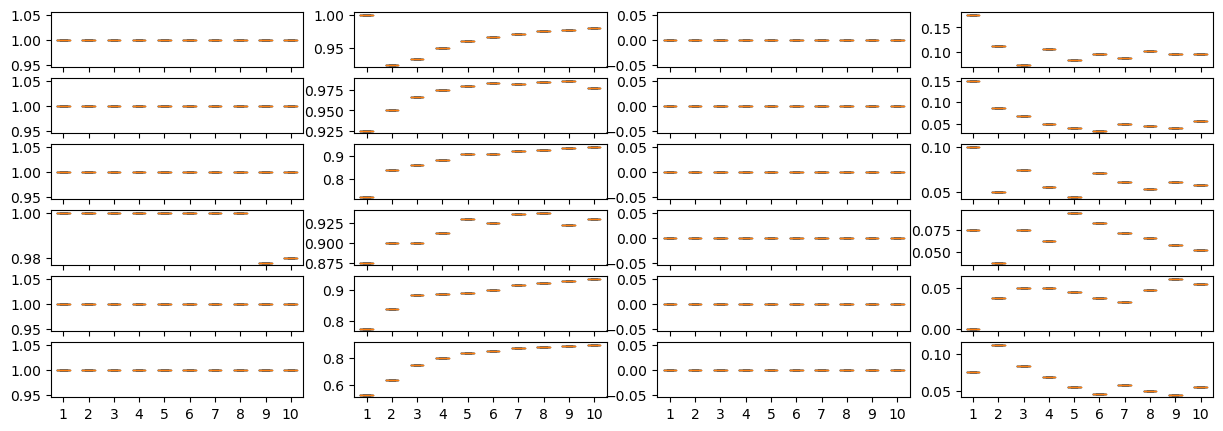

In [41]:
fig, ax = plt.subplots(ncols=4, nrows=6, figsize=(15, 5))

_ = ax[0, 0].boxplot(arr_dp_on_0)
# _ = ax[0,1].boxplot(arr_dp_off_0)
_ = ax[0, 1].boxplot(arr_dpnew_on_0)
_ = ax[0, 2].boxplot(arr_k_on_0)
_ = ax[0, 3].boxplot(arr_g_on_0)

_ = ax[1, 0].boxplot(arr_dp_on_10)
# _ = ax[1,1].boxplot(arr_dp_off_10)
_ = ax[1, 1].boxplot(arr_dpnew_on_10)
_ = ax[1, 2].boxplot(arr_k_on_10)
_ = ax[1, 3].boxplot(arr_g_on_10)

_ = ax[2, 0].boxplot(arr_dp_on_20)
# _ = ax[2,1].boxplot(arr_dp_off_20)
_ = ax[2, 1].boxplot(arr_dpnew_on_20)
_ = ax[2, 2].boxplot(arr_k_on_20)
_ = ax[2, 3].boxplot(arr_g_on_20)

_ = ax[3, 0].boxplot(arr_dp_on_30)
# _ = ax[3,1].boxplot(arr_dp_off_30)
_ = ax[3, 1].boxplot(arr_dpnew_on_30)
_ = ax[3, 2].boxplot(arr_k_on_30)
_ = ax[3, 3].boxplot(arr_g_on_30)

_ = ax[4, 0].boxplot(arr_dp_on_40)
# _ = ax[4,1].boxplot(arr_dp_off_40)
_ = ax[4, 1].boxplot(arr_dpnew_on_40)
_ = ax[4, 2].boxplot(arr_k_on_40)
_ = ax[4, 3].boxplot(arr_g_on_40)

_ = ax[5, 0].boxplot(arr_dp_on_50)
# _ = ax[5,1].boxplot(arr_dp_off_50)
_ = ax[5, 1].boxplot(arr_dpnew_on_50)
_ = ax[5, 2].boxplot(arr_k_on_50)
_ = ax[5, 3].boxplot(arr_g_on_50)

In [19]:
def removeOutliers(x, outlierConstant=1.5):
    a = np.copy(x)
    for row in a.T:
        upper_quartile = np.percentile(row, 75)
        lower_quartile = np.percentile(row, 25)
        IQR = (upper_quartile - lower_quartile) * outlierConstant
        quartileSet = (lower_quartile - IQR, upper_quartile + IQR)
        indexes_to_delete = []
        for i, item in enumerate(row):
            if item >= quartileSet[0] and item <= quartileSet[1]:
                continue
            else:
                indexes_to_delete.append(i)
        a = np.delete(a, indexes_to_delete, axis=0)
        return a

In [20]:
"""
arr_dp_on_0 = removeOutliers(arr_dp_on_0)
arr_dp_on_10 = removeOutliers(arr_dp_on_10)
arr_dp_on_20 = removeOutliers(arr_dp_on_20)
arr_dp_on_30 = removeOutliers(arr_dp_on_30)
arr_dp_on_40 = removeOutliers(arr_dp_on_40)
arr_dp_on_50 = removeOutliers(arr_dp_on_50)

arr_dpnew_on_0 = removeOutliers(arr_dpnew_on_0)
arr_dpnew_on_10 = removeOutliers(arr_dpnew_on_10)
arr_dpnew_on_20 = removeOutliers(arr_dpnew_on_20)
arr_dpnew_on_30 = removeOutliers(arr_dpnew_on_30)
arr_dpnew_on_40 = removeOutliers(arr_dpnew_on_40)
arr_dpnew_on_50 = removeOutliers(arr_dpnew_on_50)

arr_dpnew_off_0 = removeOutliers(arr_dpnew_off_0)
arr_dpnew_off_10 = removeOutliers(arr_dpnew_off_10)
arr_dpnew_off_20 = removeOutliers(arr_dpnew_off_20)
arr_dpnew_off_30 = removeOutliers(arr_dpnew_off_30)
arr_dpnew_off_40 = removeOutliers(arr_dpnew_off_40)
arr_dpnew_off_50 = removeOutliers(arr_dpnew_off_50)

arr_dp_off_0 = removeOutliers(arr_dp_off_0)
arr_dp_off_10 = removeOutliers(arr_dp_off_10)
arr_dp_off_20 = removeOutliers(arr_dp_off_20)
arr_dp_off_30 = removeOutliers(arr_dp_off_30)
arr_dp_off_40 = removeOutliers(arr_dp_off_40)
arr_dp_off_50 = removeOutliers(arr_dp_off_50)
"""

'\narr_dp_on_0 = removeOutliers(arr_dp_on_0)\narr_dp_on_10 = removeOutliers(arr_dp_on_10)\narr_dp_on_20 = removeOutliers(arr_dp_on_20)\narr_dp_on_30 = removeOutliers(arr_dp_on_30)\narr_dp_on_40 = removeOutliers(arr_dp_on_40)\narr_dp_on_50 = removeOutliers(arr_dp_on_50)\n\narr_dpnew_on_0 = removeOutliers(arr_dpnew_on_0)\narr_dpnew_on_10 = removeOutliers(arr_dpnew_on_10)\narr_dpnew_on_20 = removeOutliers(arr_dpnew_on_20)\narr_dpnew_on_30 = removeOutliers(arr_dpnew_on_30)\narr_dpnew_on_40 = removeOutliers(arr_dpnew_on_40)\narr_dpnew_on_50 = removeOutliers(arr_dpnew_on_50)\n\narr_dpnew_off_0 = removeOutliers(arr_dpnew_off_0)\narr_dpnew_off_10 = removeOutliers(arr_dpnew_off_10)\narr_dpnew_off_20 = removeOutliers(arr_dpnew_off_20)\narr_dpnew_off_30 = removeOutliers(arr_dpnew_off_30)\narr_dpnew_off_40 = removeOutliers(arr_dpnew_off_40)\narr_dpnew_off_50 = removeOutliers(arr_dpnew_off_50)\n\narr_dp_off_0 = removeOutliers(arr_dp_off_0)\narr_dp_off_10 = removeOutliers(arr_dp_off_10)\narr_dp_off_

In [21]:
mean_arr_dp_on_0 = np.mean(arr_dp_on_0, axis=0)
mean_arr_dp_on_10 = np.mean(arr_dp_on_10, axis=0)
mean_arr_dp_on_20 = np.mean(arr_dp_on_20, axis=0)
mean_arr_dp_on_30 = np.mean(arr_dp_on_30, axis=0)
mean_arr_dp_on_40 = np.mean(arr_dp_on_40, axis=0)
mean_arr_dp_on_50 = np.mean(arr_dp_on_50, axis=0)

mean_arr_dpnew_on_0 = np.mean(arr_dpnew_on_0, axis=0)
mean_arr_dpnew_on_10 = np.mean(arr_dpnew_on_10, axis=0)
mean_arr_dpnew_on_20 = np.mean(arr_dpnew_on_20, axis=0)
mean_arr_dpnew_on_30 = np.mean(arr_dpnew_on_30, axis=0)
mean_arr_dpnew_on_40 = np.mean(arr_dpnew_on_40, axis=0)
mean_arr_dpnew_on_50 = np.mean(arr_dpnew_on_50, axis=0)

mean_arr_k_on_0 = np.mean(arr_k_on_0, axis=0)
mean_arr_k_on_10 = np.mean(arr_k_on_10, axis=0)
mean_arr_k_on_20 = np.mean(arr_k_on_20, axis=0)
mean_arr_k_on_30 = np.mean(arr_k_on_30, axis=0)
mean_arr_k_on_40 = np.mean(arr_k_on_40, axis=0)
mean_arr_k_on_50 = np.mean(arr_k_on_50, axis=0)

mean_arr_g_on_0 = np.mean(arr_g_on_0, axis=0)
mean_arr_g_on_10 = np.mean(arr_g_on_10, axis=0)
mean_arr_g_on_20 = np.mean(arr_g_on_20, axis=0)
mean_arr_g_on_30 = np.mean(arr_g_on_30, axis=0)
mean_arr_g_on_40 = np.mean(arr_g_on_40, axis=0)
mean_arr_g_on_50 = np.mean(arr_g_on_50, axis=0)

"""
mean_arr_dpnew_off_0 = np.mean(arr_dpnew_off_0, axis=0)
mean_arr_dpnew_off_10 = np.mean(arr_dpnew_off_10, axis=0)
mean_arr_dpnew_off_20 = np.mean(arr_dpnew_off_20, axis=0)
mean_arr_dpnew_off_30 = np.mean(arr_dpnew_off_30, axis=0)
mean_arr_dpnew_off_40 = np.mean(arr_dpnew_off_40, axis=0)
mean_arr_dpnew_off_50 = np.mean(arr_dpnew_off_50, axis=0)

mean_arr_dp_off_0 = np.mean(arr_dp_off_0, axis=0)
mean_arr_dp_off_10 = np.mean(arr_dp_off_10, axis=0)
mean_arr_dp_off_20 = np.mean(arr_dp_off_20, axis=0)
mean_arr_dp_off_30 = np.mean(arr_dp_off_30, axis=0)
mean_arr_dp_off_40 = np.mean(arr_dp_off_40, axis=0)
mean_arr_dp_off_50 = np.mean(arr_dp_off_50, axis=0)
"""

'\nmean_arr_dpnew_off_0 = np.mean(arr_dpnew_off_0, axis=0)\nmean_arr_dpnew_off_10 = np.mean(arr_dpnew_off_10, axis=0)\nmean_arr_dpnew_off_20 = np.mean(arr_dpnew_off_20, axis=0)\nmean_arr_dpnew_off_30 = np.mean(arr_dpnew_off_30, axis=0)\nmean_arr_dpnew_off_40 = np.mean(arr_dpnew_off_40, axis=0)\nmean_arr_dpnew_off_50 = np.mean(arr_dpnew_off_50, axis=0)\n\nmean_arr_dp_off_0 = np.mean(arr_dp_off_0, axis=0)\nmean_arr_dp_off_10 = np.mean(arr_dp_off_10, axis=0)\nmean_arr_dp_off_20 = np.mean(arr_dp_off_20, axis=0)\nmean_arr_dp_off_30 = np.mean(arr_dp_off_30, axis=0)\nmean_arr_dp_off_40 = np.mean(arr_dp_off_40, axis=0)\nmean_arr_dp_off_50 = np.mean(arr_dp_off_50, axis=0)\n'

In [22]:
prob = [0, 0.1, 0.2, 0.3, 0.4, 0.5]
flows = np.arange(STEPS, NUMBER_OF_FLOWS + STEPS, step=STEPS)
[FLOWS, PROB] = np.meshgrid(flows, prob)

ar_1 = np.vstack(
    (
        mean_arr_dp_on_0,
        mean_arr_dp_on_10,
        mean_arr_dp_on_20,
        mean_arr_dp_on_30,
        mean_arr_dp_on_40,
        mean_arr_dp_on_50,
    )
)
ar_2 = np.vstack(
    (
        mean_arr_dpnew_on_0,
        mean_arr_dpnew_on_10,
        mean_arr_dpnew_on_20,
        mean_arr_dpnew_on_30,
        mean_arr_dpnew_on_40,
        mean_arr_dpnew_on_50,
    )
)
ar_3 = np.vstack(
    (
        mean_arr_k_on_0,
        mean_arr_k_on_10,
        mean_arr_k_on_20,
        mean_arr_k_on_30,
        mean_arr_k_on_40,
        mean_arr_k_on_50,
    )
)
# ar_3 = np.vstack((mean_arr_dpnew_off_0, mean_arr_dpnew_off_10, mean_arr_dpnew_off_20,
#    mean_arr_dpnew_off_30, mean_arr_dpnew_off_40, mean_arr_dpnew_off_50))

ar_4 = np.vstack(
    (
        mean_arr_g_on_0,
        mean_arr_g_on_10,
        mean_arr_g_on_20,
        mean_arr_g_on_30,
        mean_arr_g_on_40,
        mean_arr_g_on_50,
    )
)
"""
ar_5 = np.vstack((mean_arr_b_off_0, mean_arr_b_off_15, mean_arr_b_off_3))
ar_6 = np.vstack((mean_arr_g_off_0, mean_arr_g_off_15, mean_arr_g_off_3))
"""

'\nar_5 = np.vstack((mean_arr_b_off_0, mean_arr_b_off_15, mean_arr_b_off_3))\nar_6 = np.vstack((mean_arr_g_off_0, mean_arr_g_off_15, mean_arr_g_off_3))\n'

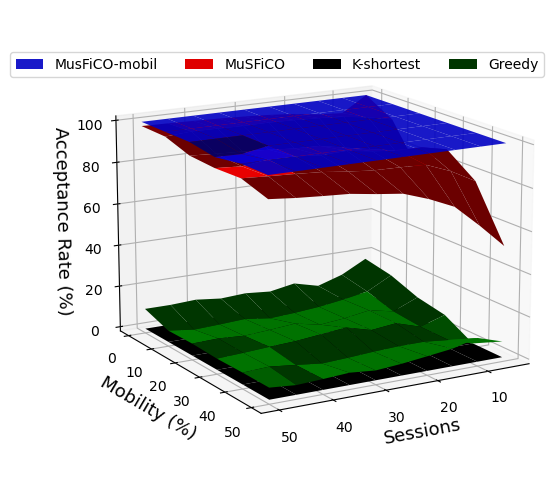

In [42]:
fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(15, 5))

plt.rcParams["axes.labelsize"] = 13

c0 = ax.plot_surface(FLOWS, PROB, ar_1 * 100, color="blue", label="MusFiCO-mobil", alpha=0.9)
c1 = ax.plot_surface(FLOWS, PROB, ar_2 * 100, color="red", label="MuSFiCO")
c2 = ax.plot_surface(FLOWS, PROB, ar_3 * 100, color="black", label="K-shortest")
c3 = ax.plot_surface(FLOWS, PROB, ar_4 * 100, color="green", label="Greedy")

ax.set_xlabel("Sessions")
ax.set_ylabel("Mobility (%)")
ax.set_zlabel("Acceptance Rate (%)")
ax.set_yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5], [0, 10, 20, 30, 40, 50])
ax.view_init(15, 60)
c0._facecolors2d = c0._facecolor3d
c0._edgecolors2d = c0._edgecolor3d
c1._facecolors2d = c1._facecolor3d
c1._edgecolors2d = c1._edgecolor3d
c2._facecolors2d = c2._facecolor3d
c2._edgecolors2d = c2._edgecolor3d
c3._facecolors2d = c3._facecolor3d
c3._edgecolors2d = c3._edgecolor3d
fig.tight_layout()
fig.legend(bbox_to_anchor=(0.5, 0.9), fontsize=10, ncol=4)
# fig.savefig('figures/plot_3d_ar.pdf')

/tmp/ipykernel_118105/1825066865.py:70: UserWarning: FixedFormatter should only be used together with FixedLocator
  cbar.set_ticklabels([0, 20, 40, 60, 80, 100])
/tmp/ipykernel_118105/1825066865.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


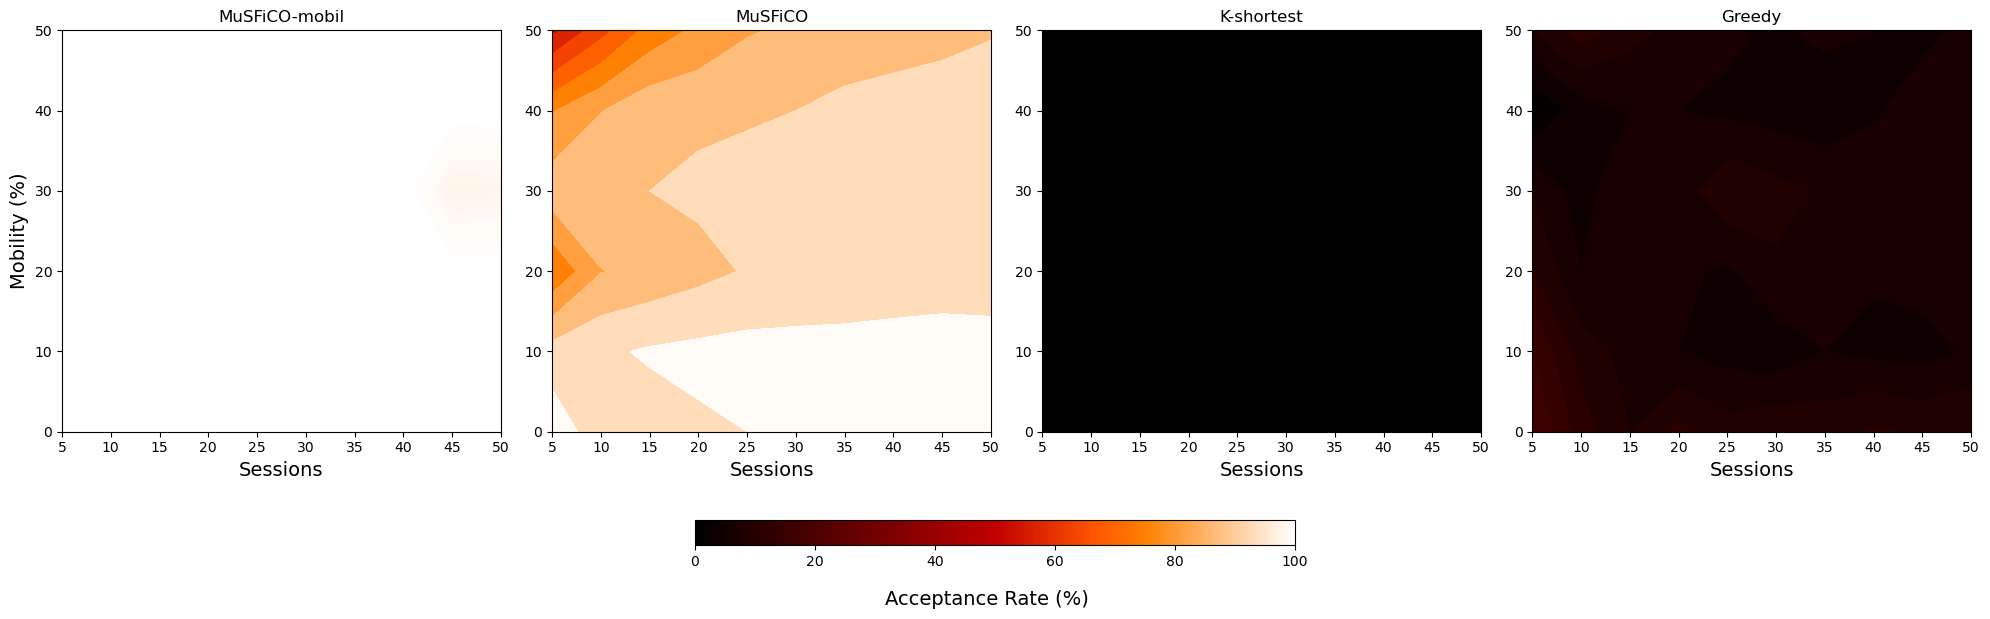

In [24]:
import seaborn as sns
import matplotlib as mpl

plt.rcParams["axes.labelsize"] = 14

cmap = sns.color_palette("gist_heat", as_cmap=True)

vmin = (
    np.amin([np.amin(np.hstack(ar_1)), np.amin(np.hstack(ar_3)), np.amin(np.hstack(ar_2))]) * 100
)
vmax = (
    np.amax([np.amax(np.hstack(ar_1)), np.amax(np.hstack(ar_3)), np.amax(np.hstack(ar_2))]) * 100
)

# norm = colors.Normalize(vmin=vmin, vmax=vmax)

fig, ax = plt.subplots(ncols=4, figsize=(20, 5))
ax[0].contourf(FLOWS, PROB * 100, ar_1 * 100, cmap=cmap, vmin=vmin, vmax=vmax)
ax[0].set_ylabel("Mobility (%)")
ax[0].set_xlabel("Sessions")
ax[0].set_title("MuSFiCO-mobil")
ax[0].set_xticks(flows)
# ax[0].set_yticks([0, 10, 20, 30, 40, 50], [0, 10, 20, 30, 40, 50])

ax[1].contourf(FLOWS, PROB * 100, ar_2 * 100, cmap=cmap, vmin=vmin, vmax=vmax)
ax[1].set_xlabel("Sessions")
ax[1].set_title("MuSFiCO")
ax[1].set_xticks(flows)
# ax[1].set_yticks([0, 10, 20, 30, 40, 50], [0, 10, 20, 30, 40, 50])

ax[2].contourf(FLOWS, PROB * 100, ar_3 * 100, cmap=cmap, vmin=vmin, vmax=vmax)
ax[2].set_xlabel("Sessions")
ax[2].set_title("K-shortest")
ax[2].set_xticks(flows)
# ax[2].set_yticks([0, 10, 20, 30, 40, 50], [0, 10, 20, 30, 40, 50])


ax[3].contourf(FLOWS, PROB * 100, ar_4 * 100, cmap=cmap, vmin=vmin, vmax=vmax)
ax[3].set_xlabel("Sessions")
ax[3].set_title("Greedy")
ax[3].set_xticks(flows)
# ax[3].set_yticks([0, 10, 20, 30, 40, 50], [0, 10, 20, 30, 40, 50])

"""
ax[4].contourf(FLOWS, PROB * 100, ar_5 * 100, cmap=cmap, vmin=vmin, vmax=vmax)
ax[4].set_ylabel('Mobility (%)')
ax[4].set_xlabel('Sessions')
ax[4].set_title('BC SFC OFF')

ax[5].contourf(FLOWS, PROB * 100, ar_6 * 100, cmap=cmap, vmin=vmin, vmax=vmax)
ax[5].set_ylabel('Mobility (%)')
ax[5].set_xlabel('Sessions')
ax[5].set_title('Greedy SFC OFF')
"""
# position for the colorbar
fig.subplots_adjust()
# = fig.add_axes([0.35, -0.1 ,0.3 ,0.05])
# fig.colorbar(heat, orientation='horizontal', cax=cbar_ax)
cbar_ax = fig.add_axes([0.35, -0.1, 0.3, 0.05])
# cbar_ax.axes.get_xaxis().set_visible(False)
# cbar_ax.axes.get_yaxis().set_visible(False)
ax_3 = fig.text(x=0.445, y=-0.22, s="Acceptance Rate (%)", fontsize=14)
# ax_1 = fig.text(x=0.344, y=-0.14, s='0', fontsize=14)
# ax_2 = fig.text(x=0.64, y=-0.14, s='100', fontsize=14)
cbar = mpl.colorbar.ColorbarBase(cbar_ax, cmap=cmap, orientation="horizontal")
cbar.set_ticklabels([0, 20, 40, 60, 80, 100])
fig.tight_layout()
# fig.savefig('figures/heatmap.png', bbox_extra_artists=(cbar_ax, ax_3, ), bbox_inches='tight')
# TODO ADD LEGEND, ADD SCALE [0,1] TO COLORBAR

In [26]:
parameter = "bandwidth_utilization"

In [27]:
parameter_beautify_name = {
    "cache_utilization": "Cache (%)",
    "duration": "Decision time (s)",
    "latency": "Latency (ms)",
    "bandwidth_utilization": "Bandwidth (%)",
    "cpu_utilization": "CPU (%)",
}
parameter_name = parameter_beautify_name[parameter]

if parameter == "latency" or parameter == "duration":
    PERCENTAGE = 1
    df_resource_filtered = df[df["latency"] >= 0]
else:
    PERCENTAGE = 100
    df_resource_filtered = df.copy()

arr_dp_on_0_resource = [
    resource_utilization(
        df_resource_filtered[
            (df_resource_filtered["algorithm"] == "dp")
            & (
                df_resource_filtered["n_execution"]
                == indexes_array_sfc_on_executions["dp"]["0.0"][i]
            )
            & (df_resource_filtered["prob"] == "0.0")
            & (df_resource_filtered["sfc"] == "on")
        ].reset_index()[parameter],
        arr[0],
        sfc_type="on",
    )
    for i, arr in enumerate(indexes_array_sfc_on["dp"]["0.0"])
]

arr_dp_on_10_resource = [
    resource_utilization(
        df_resource_filtered[
            (df_resource_filtered["algorithm"] == "dp")
            & (
                df_resource_filtered["n_execution"]
                == indexes_array_sfc_on_executions["dp"]["0.1"][i]
            )
            & (df_resource_filtered["prob"] == "0.1")
            & (df_resource_filtered["sfc"] == "on")
        ].reset_index()[parameter],
        arr[0],
        sfc_type="on",
    )
    for i, arr in enumerate(indexes_array_sfc_on["dp"]["0.1"])
]

arr_dp_on_20_resource = [
    resource_utilization(
        df_resource_filtered[
            (df_resource_filtered["algorithm"] == "dp")
            & (
                df_resource_filtered["n_execution"]
                == indexes_array_sfc_on_executions["dp"]["0.2"][i]
            )
            & (df_resource_filtered["prob"] == "0.2")
            & (df_resource_filtered["sfc"] == "on")
        ].reset_index()[parameter],
        arr[0],
        sfc_type="on",
    )
    for i, arr in enumerate(indexes_array_sfc_on["dp"]["0.2"])
]

arr_dp_on_30_resource = [
    resource_utilization(
        df_resource_filtered[
            (df_resource_filtered["algorithm"] == "dp")
            & (
                df_resource_filtered["n_execution"]
                == indexes_array_sfc_on_executions["dp"]["0.3"][i]
            )
            & (df_resource_filtered["prob"] == "0.3")
            & (df_resource_filtered["sfc"] == "on")
        ].reset_index()[parameter],
        arr[0],
        sfc_type="on",
    )
    for i, arr in enumerate(indexes_array_sfc_on["dp"]["0.3"])
]

arr_dp_on_40_resource = [
    resource_utilization(
        df_resource_filtered[
            (df_resource_filtered["algorithm"] == "dp")
            & (
                df_resource_filtered["n_execution"]
                == indexes_array_sfc_on_executions["dp"]["0.4"][i]
            )
            & (df_resource_filtered["prob"] == "0.4")
            & (df_resource_filtered["sfc"] == "on")
        ].reset_index()[parameter],
        arr[0],
        sfc_type="on",
    )
    for i, arr in enumerate(indexes_array_sfc_on["dp"]["0.4"])
]

arr_dp_on_50_resource = [
    resource_utilization(
        df_resource_filtered[
            (df_resource_filtered["algorithm"] == "dp")
            & (
                df_resource_filtered["n_execution"]
                == indexes_array_sfc_on_executions["dp"]["0.5"][i]
            )
            & (df_resource_filtered["prob"] == "0.5")
            & (df_resource_filtered["sfc"] == "on")
        ].reset_index()[parameter],
        arr[0],
        sfc_type="on",
    )
    for i, arr in enumerate(indexes_array_sfc_on["dp"]["0.5"])
]


arr_dpnew_on_0_resource = [
    resource_utilization(
        df_resource_filtered[
            (df_resource_filtered["algorithm"] == "musfico")
            & (
                df_resource_filtered["n_execution"]
                == indexes_array_sfc_on_executions["musfico"]["0.0"][i]
            )
            & (df_resource_filtered["prob"] == "0.0")
            & (df_resource_filtered["sfc"] == "on")
        ].reset_index()[parameter],
        arr[0],
        sfc_type="on",
    )
    for i, arr in enumerate(indexes_array_sfc_on["musfico"]["0.0"])
]

arr_dpnew_on_10_resource = [
    resource_utilization(
        df_resource_filtered[
            (df_resource_filtered["algorithm"] == "musfico")
            & (
                df_resource_filtered["n_execution"]
                == indexes_array_sfc_on_executions["musfico"]["0.1"][i]
            )
            & (df_resource_filtered["prob"] == "0.1")
            & (df_resource_filtered["sfc"] == "on")
        ].reset_index()[parameter],
        arr[0],
        sfc_type="on",
    )
    for i, arr in enumerate(indexes_array_sfc_on["musfico"]["0.1"])
]

arr_dpnew_on_20_resource = [
    resource_utilization(
        df_resource_filtered[
            (df_resource_filtered["algorithm"] == "musfico")
            & (
                df_resource_filtered["n_execution"]
                == indexes_array_sfc_on_executions["musfico"]["0.2"][i]
            )
            & (df_resource_filtered["prob"] == "0.2")
            & (df_resource_filtered["sfc"] == "on")
        ].reset_index()[parameter],
        arr[0],
        sfc_type="on",
    )
    for i, arr in enumerate(indexes_array_sfc_on["musfico"]["0.2"])
]

arr_dpnew_on_30_resource = [
    resource_utilization(
        df_resource_filtered[
            (df_resource_filtered["algorithm"] == "musfico")
            & (
                df_resource_filtered["n_execution"]
                == indexes_array_sfc_on_executions["musfico"]["0.3"][i]
            )
            & (df_resource_filtered["prob"] == "0.3")
            & (df_resource_filtered["sfc"] == "on")
        ].reset_index()[parameter],
        arr[0],
        sfc_type="on",
    )
    for i, arr in enumerate(indexes_array_sfc_on["musfico"]["0.3"])
]

arr_dpnew_on_40_resource = [
    resource_utilization(
        df_resource_filtered[
            (df_resource_filtered["algorithm"] == "musfico")
            & (
                df_resource_filtered["n_execution"]
                == indexes_array_sfc_on_executions["musfico"]["0.4"][i]
            )
            & (df_resource_filtered["prob"] == "0.4")
            & (df_resource_filtered["sfc"] == "on")
        ].reset_index()[parameter],
        arr[0],
        sfc_type="on",
    )
    for i, arr in enumerate(indexes_array_sfc_on["musfico"]["0.4"])
]

arr_dpnew_on_50_resource = [
    resource_utilization(
        df_resource_filtered[
            (df_resource_filtered["algorithm"] == "musfico")
            & (
                df_resource_filtered["n_execution"]
                == indexes_array_sfc_on_executions["musfico"]["0.5"][i]
            )
            & (df_resource_filtered["prob"] == "0.5")
            & (df_resource_filtered["sfc"] == "on")
        ].reset_index()[parameter],
        arr[0],
        sfc_type="on",
    )
    for i, arr in enumerate(indexes_array_sfc_on["musfico"]["0.5"])
]

arr_k_on_0_resource = [
    resource_utilization(
        df_resource_filtered[
            (df_resource_filtered["algorithm"] == "k")
            & (
                df_resource_filtered["n_execution"]
                == indexes_array_sfc_on_executions["k"]["0.0"][i]
            )
            & (df_resource_filtered["prob"] == "0.0")
            & (df_resource_filtered["sfc"] == "on")
        ].reset_index()[parameter],
        arr[0],
        sfc_type="on",
    )
    for i, arr in enumerate(indexes_array_sfc_on["k"]["0.0"])
]

arr_k_on_10_resource = [
    resource_utilization(
        df_resource_filtered[
            (df_resource_filtered["algorithm"] == "k")
            & (
                df_resource_filtered["n_execution"]
                == indexes_array_sfc_on_executions["k"]["0.1"][i]
            )
            & (df_resource_filtered["prob"] == "0.1")
            & (df_resource_filtered["sfc"] == "on")
        ].reset_index()[parameter],
        arr[0],
        sfc_type="on",
    )
    for i, arr in enumerate(indexes_array_sfc_on["k"]["0.1"])
]

arr_k_on_20_resource = [
    resource_utilization(
        df_resource_filtered[
            (df_resource_filtered["algorithm"] == "k")
            & (
                df_resource_filtered["n_execution"]
                == indexes_array_sfc_on_executions["k"]["0.2"][i]
            )
            & (df_resource_filtered["prob"] == "0.2")
            & (df_resource_filtered["sfc"] == "on")
        ].reset_index()[parameter],
        arr[0],
        sfc_type="on",
    )
    for i, arr in enumerate(indexes_array_sfc_on["k"]["0.2"])
]

arr_k_on_30_resource = [
    resource_utilization(
        df_resource_filtered[
            (df_resource_filtered["algorithm"] == "k")
            & (
                df_resource_filtered["n_execution"]
                == indexes_array_sfc_on_executions["k"]["0.3"][i]
            )
            & (df_resource_filtered["prob"] == "0.3")
            & (df_resource_filtered["sfc"] == "on")
        ].reset_index()[parameter],
        arr[0],
        sfc_type="on",
    )
    for i, arr in enumerate(indexes_array_sfc_on["k"]["0.3"])
]

arr_k_on_40_resource = [
    resource_utilization(
        df_resource_filtered[
            (df_resource_filtered["algorithm"] == "k")
            & (
                df_resource_filtered["n_execution"]
                == indexes_array_sfc_on_executions["k"]["0.4"][i]
            )
            & (df_resource_filtered["prob"] == "0.4")
            & (df_resource_filtered["sfc"] == "on")
        ].reset_index()[parameter],
        arr[0],
        sfc_type="on",
    )
    for i, arr in enumerate(indexes_array_sfc_on["k"]["0.4"])
]

arr_k_on_50_resource = [
    resource_utilization(
        df_resource_filtered[
            (df_resource_filtered["algorithm"] == "k")
            & (
                df_resource_filtered["n_execution"]
                == indexes_array_sfc_on_executions["k"]["0.5"][i]
            )
            & (df_resource_filtered["prob"] == "0.5")
            & (df_resource_filtered["sfc"] == "on")
        ].reset_index()[parameter],
        arr[0],
        sfc_type="on",
    )
    for i, arr in enumerate(indexes_array_sfc_on["k"]["0.5"])
]

arr_g_on_0_resource = [
    resource_utilization(
        df_resource_filtered[
            (df_resource_filtered["algorithm"] == "g")
            & (
                df_resource_filtered["n_execution"]
                == indexes_array_sfc_on_executions["g"]["0.0"][i]
            )
            & (df_resource_filtered["prob"] == "0.0")
            & (df_resource_filtered["sfc"] == "on")
        ].reset_index()[parameter],
        arr[0],
        sfc_type="on",
    )
    for i, arr in enumerate(indexes_array_sfc_on["g"]["0.0"])
]

arr_g_on_10_resource = [
    resource_utilization(
        df_resource_filtered[
            (df_resource_filtered["algorithm"] == "g")
            & (
                df_resource_filtered["n_execution"]
                == indexes_array_sfc_on_executions["g"]["0.1"][i]
            )
            & (df_resource_filtered["prob"] == "0.1")
            & (df_resource_filtered["sfc"] == "on")
        ].reset_index()[parameter],
        arr[0],
        sfc_type="on",
    )
    for i, arr in enumerate(indexes_array_sfc_on["g"]["0.1"])
]

arr_g_on_20_resource = [
    resource_utilization(
        df_resource_filtered[
            (df_resource_filtered["algorithm"] == "g")
            & (
                df_resource_filtered["n_execution"]
                == indexes_array_sfc_on_executions["g"]["0.2"][i]
            )
            & (df_resource_filtered["prob"] == "0.2")
            & (df_resource_filtered["sfc"] == "on")
        ].reset_index()[parameter],
        arr[0],
        sfc_type="on",
    )
    for i, arr in enumerate(indexes_array_sfc_on["g"]["0.2"])
]

arr_g_on_30_resource = [
    resource_utilization(
        df_resource_filtered[
            (df_resource_filtered["algorithm"] == "g")
            & (
                df_resource_filtered["n_execution"]
                == indexes_array_sfc_on_executions["g"]["0.3"][i]
            )
            & (df_resource_filtered["prob"] == "0.3")
            & (df_resource_filtered["sfc"] == "on")
        ].reset_index()[parameter],
        arr[0],
        sfc_type="on",
    )
    for i, arr in enumerate(indexes_array_sfc_on["g"]["0.3"])
]

arr_g_on_40_resource = [
    resource_utilization(
        df_resource_filtered[
            (df_resource_filtered["algorithm"] == "g")
            & (
                df_resource_filtered["n_execution"]
                == indexes_array_sfc_on_executions["g"]["0.4"][i]
            )
            & (df_resource_filtered["prob"] == "0.4")
            & (df_resource_filtered["sfc"] == "on")
        ].reset_index()[parameter],
        arr[0],
        sfc_type="on",
    )
    for i, arr in enumerate(indexes_array_sfc_on["g"]["0.4"])
]

arr_g_on_50_resource = [
    resource_utilization(
        df_resource_filtered[
            (df_resource_filtered["algorithm"] == "g")
            & (
                df_resource_filtered["n_execution"]
                == indexes_array_sfc_on_executions["g"]["0.5"][i]
            )
            & (df_resource_filtered["prob"] == "0.5")
            & (df_resource_filtered["sfc"] == "on")
        ].reset_index()[parameter],
        arr[0],
        sfc_type="on",
    )
    for i, arr in enumerate(indexes_array_sfc_on["g"]["0.5"])
]

In [28]:
"""
arr_dpnew_off_0_resource = [resource_utilization(df_resource_filtered[(df_resource_filtered['algorithm'] == 'musfico') & 
(df_resource_filtered['n_execution'] == indexes_array_sfc_off_executions['musfico']['0.0'][i]) & (df_resource_filtered['prob'] == '0.0') & 
(df_resource_filtered['sfc'] == 'off')].reset_index()[parameter], arr[0] ,sfc_type='off') for i, arr in enumerate(indexes_array_sfc_off['musfico']['0.0'])]

arr_dpnew_off_10_resource = [resource_utilization(df_resource_filtered[(df_resource_filtered['algorithm'] == 'musfico') & 
(df_resource_filtered['n_execution'] == indexes_array_sfc_off_executions['musfico']['0.1'][i]) & (df_resource_filtered['prob'] == '0.1') & 
(df_resource_filtered['sfc'] == 'off')].reset_index()[parameter], arr[0] ,sfc_type='off') for i, arr in enumerate(indexes_array_sfc_off['musfico']['0.1'])]

arr_dpnew_off_20_resource = [resource_utilization(df_resource_filtered[(df_resource_filtered['algorithm'] == 'musfico') & 
(df_resource_filtered['n_execution'] == indexes_array_sfc_off_executions['musfico']['0.2'][i]) & (df_resource_filtered['prob'] == '0.2') & 
(df_resource_filtered['sfc'] == 'off')].reset_index()[parameter], arr[0] ,sfc_type='off') for i, arr in enumerate(indexes_array_sfc_off['musfico']['0.2'])]

arr_dpnew_off_30_resource = [resource_utilization(df_resource_filtered[(df_resource_filtered['algorithm'] == 'musfico') & 
(df_resource_filtered['n_execution'] == indexes_array_sfc_off_executions['musfico']['0.3'][i]) & (df_resource_filtered['prob'] == '0.3') & 
(df_resource_filtered['sfc'] == 'off')].reset_index()[parameter], arr[0] ,sfc_type='off') for i, arr in enumerate(indexes_array_sfc_off['musfico']['0.3'])]

arr_dpnew_off_40_resource = [resource_utilization(df_resource_filtered[(df_resource_filtered['algorithm'] == 'musfico') & 
(df_resource_filtered['n_execution'] == indexes_array_sfc_off_executions['musfico']['0.4'][i]) & (df_resource_filtered['prob'] == '0.4') & 
(df_resource_filtered['sfc'] == 'off')].reset_index()[parameter], arr[0] ,sfc_type='off') for i, arr in enumerate(indexes_array_sfc_off['musfico']['0.4'])]

arr_dpnew_off_50_resource = [resource_utilization(df_resource_filtered[(df_resource_filtered['algorithm'] == 'musfico') & 
(df_resource_filtered['n_execution'] == indexes_array_sfc_off_executions['musfico']['0.5'][i]) & (df_resource_filtered['prob'] == '0.5') & 
(df_resource_filtered['sfc'] == 'off')].reset_index()[parameter], arr[0] ,sfc_type='off') for i, arr in enumerate(indexes_array_sfc_off['musfico']['0.5'])]


arr_dp_off_0_resource = [resource_utilization(df_resource_filtered[(df_resource_filtered['algorithm'] == 'dp') & 
(df_resource_filtered['n_execution'] == indexes_array_sfc_off_executions['dp']['0.0'][i]) & (df_resource_filtered['prob'] == '0.0') & 
(df_resource_filtered['sfc'] == 'off')].reset_index()[parameter], arr[0] ,sfc_type='off') for i, arr in enumerate(indexes_array_sfc_off['dp']['0.0'])]

arr_dp_off_10_resource = [resource_utilization(df_resource_filtered[(df_resource_filtered['algorithm'] == 'dp') & 
(df_resource_filtered['n_execution'] == indexes_array_sfc_off_executions['dp']['0.1'][i]) & (df_resource_filtered['prob'] == '0.1') & 
(df_resource_filtered['sfc'] == 'off')].reset_index()[parameter], arr[0] ,sfc_type='off') for i, arr in enumerate(indexes_array_sfc_off['dp']['0.1'])]

arr_dp_off_20_resource = [resource_utilization(df_resource_filtered[(df_resource_filtered['algorithm'] == 'dp') & 
(df_resource_filtered['n_execution'] == indexes_array_sfc_off_executions['dp']['0.2'][i]) & (df_resource_filtered['prob'] == '0.2') & 
(df_resource_filtered['sfc'] == 'off')].reset_index()[parameter], arr[0] ,sfc_type='off') for i, arr in enumerate(indexes_array_sfc_off['dp']['0.2'])]

arr_dp_off_30_resource = [resource_utilization(df_resource_filtered[(df_resource_filtered['algorithm'] == 'dp') & 
(df_resource_filtered['n_execution'] == indexes_array_sfc_off_executions['dp']['0.3'][i]) & (df_resource_filtered['prob'] == '0.3') & 
(df_resource_filtered['sfc'] == 'off')].reset_index()[parameter], arr[0] ,sfc_type='off') for i, arr in enumerate(indexes_array_sfc_off['dp']['0.3'])]

arr_dp_off_40_resource = [resource_utilization(df_resource_filtered[(df_resource_filtered['algorithm'] == 'dp') & 
(df_resource_filtered['n_execution'] == indexes_array_sfc_off_executions['dp']['0.4'][i]) & (df_resource_filtered['prob'] == '0.4') & 
(df_resource_filtered['sfc'] == 'off')].reset_index()[parameter], arr[0] ,sfc_type='off') for i, arr in enumerate(indexes_array_sfc_off['dp']['0.4'])]

arr_dp_off_50_resource = [resource_utilization(df_resource_filtered[(df_resource_filtered['algorithm'] == 'dp') & 
(df_resource_filtered['n_execution'] == indexes_array_sfc_off_executions['dp']['0.5'][i]) & (df_resource_filtered['prob'] == '0.5') & 
(df_resource_filtered['sfc'] == 'off')].reset_index()[parameter], arr[0] ,sfc_type='off') for i, arr in enumerate(indexes_array_sfc_off['dp']['0.5'])]

"""

"\narr_dpnew_off_0_resource = [resource_utilization(df_resource_filtered[(df_resource_filtered['algorithm'] == 'musfico') & \n(df_resource_filtered['n_execution'] == indexes_array_sfc_off_executions['musfico']['0.0'][i]) & (df_resource_filtered['prob'] == '0.0') & \n(df_resource_filtered['sfc'] == 'off')].reset_index()[parameter], arr[0] ,sfc_type='off') for i, arr in enumerate(indexes_array_sfc_off['musfico']['0.0'])]\n\narr_dpnew_off_10_resource = [resource_utilization(df_resource_filtered[(df_resource_filtered['algorithm'] == 'musfico') & \n(df_resource_filtered['n_execution'] == indexes_array_sfc_off_executions['musfico']['0.1'][i]) & (df_resource_filtered['prob'] == '0.1') & \n(df_resource_filtered['sfc'] == 'off')].reset_index()[parameter], arr[0] ,sfc_type='off') for i, arr in enumerate(indexes_array_sfc_off['musfico']['0.1'])]\n\narr_dpnew_off_20_resource = [resource_utilization(df_resource_filtered[(df_resource_filtered['algorithm'] == 'musfico') & \n(df_resource_filtered['n_e

In [29]:
arr_dp_on_0_resource = np.array(list(filter(lambda x: len(x) > 0, arr_dp_on_0_resource)))
arr_dp_on_10_resource = np.array(list(filter(lambda x: len(x) > 0, arr_dp_on_10_resource)))
arr_dp_on_20_resource = np.array(list(filter(lambda x: len(x) > 0, arr_dp_on_20_resource)))
arr_dp_on_30_resource = np.array(list(filter(lambda x: len(x) > 0, arr_dp_on_30_resource)))
arr_dp_on_40_resource = np.array(list(filter(lambda x: len(x) > 0, arr_dp_on_40_resource)))
arr_dp_on_50_resource = np.array(list(filter(lambda x: len(x) > 0, arr_dp_on_50_resource)))
"""
arr_dp_off_0_resource =  np.array(list(filter(lambda x: len(x) > 0, arr_dp_off_0_resource)))
arr_dp_off_10_resource =  np.array(list(filter(lambda x: len(x) > 0, arr_dp_off_10_resource)))
arr_dp_off_20_resource =  np.array(list(filter(lambda x: len(x) > 0, arr_dp_off_20_resource)))
arr_dp_off_30_resource =  np.array(list(filter(lambda x: len(x) > 0, arr_dp_off_30_resource)))
arr_dp_off_40_resource =  np.array(list(filter(lambda x: len(x) > 0, arr_dp_off_40_resource)))
arr_dp_off_50_resource =  np.array(list(filter(lambda x: len(x) > 0, arr_dp_off_50_resource)))
"""
arr_dpnew_on_0_resource = np.array(list(filter(lambda x: len(x) > 0, arr_dpnew_on_0_resource)))
arr_dpnew_on_10_resource = np.array(list(filter(lambda x: len(x) > 0, arr_dpnew_on_10_resource)))
arr_dpnew_on_20_resource = np.array(list(filter(lambda x: len(x) > 0, arr_dpnew_on_20_resource)))
arr_dpnew_on_30_resource = np.array(list(filter(lambda x: len(x) > 0, arr_dpnew_on_30_resource)))
arr_dpnew_on_40_resource = np.array(list(filter(lambda x: len(x) > 0, arr_dpnew_on_40_resource)))
arr_dpnew_on_50_resource = np.array(list(filter(lambda x: len(x) > 0, arr_dpnew_on_50_resource)))
"""
arr_dpnew_off_0_resource =  np.array(list(filter(lambda x: len(x) > 0, arr_dpnew_off_0_resource)))
arr_dpnew_off_10_resource =  np.array(list(filter(lambda x: len(x) > 0, arr_dpnew_off_10_resource)))
arr_dpnew_off_20_resource=  np.array(list(filter(lambda x: len(x) > 0, arr_dpnew_off_20_resource)))
arr_dpnew_off_30_resource =  np.array(list(filter(lambda x: len(x) > 0, arr_dpnew_off_30_resource)))
arr_dpnew_off_40_resource =  np.array(list(filter(lambda x: len(x) > 0, arr_dpnew_off_40_resource)))
arr_dpnew_off_50_resource=  np.array(list(filter(lambda x: len(x) > 0, arr_dpnew_off_50_resource)))
"""
arr_k_on_0_resource = np.array(list(filter(lambda x: len(x) > 0, arr_k_on_0_resource)))
arr_k_on_10_resource = np.array(list(filter(lambda x: len(x) > 0, arr_k_on_10_resource)))
arr_k_on_20_resource = np.array(list(filter(lambda x: len(x) > 0, arr_k_on_20_resource)))
arr_k_on_30_resource = np.array(list(filter(lambda x: len(x) > 0, arr_k_on_30_resource)))
arr_k_on_40_resource = np.array(list(filter(lambda x: len(x) > 0, arr_k_on_40_resource)))
arr_k_on_50_resource = np.array(list(filter(lambda x: len(x) > 0, arr_k_on_50_resource)))

arr_g_on_0_resource = np.array(list(filter(lambda x: len(x) > 0, arr_g_on_0_resource)))
arr_g_on_10_resource = np.array(list(filter(lambda x: len(x) > 0, arr_g_on_10_resource)))
arr_g_on_20_resource = np.array(list(filter(lambda x: len(x) > 0, arr_g_on_20_resource)))
arr_g_on_30_resource = np.array(list(filter(lambda x: len(x) > 0, arr_g_on_30_resource)))
arr_g_on_40_resource = np.array(list(filter(lambda x: len(x) > 0, arr_g_on_40_resource)))
arr_g_on_50_resource = np.array(list(filter(lambda x: len(x) > 0, arr_g_on_50_resource)))

In [30]:
arr_dp_on_0_resource = np.vstack(arr_dp_on_0_resource)
arr_dp_on_10_resource = np.vstack(arr_dp_on_10_resource)
arr_dp_on_20_resource = np.vstack(arr_dp_on_20_resource)
arr_dp_on_30_resource = np.vstack(arr_dp_on_30_resource)
arr_dp_on_40_resource = np.vstack(arr_dp_on_40_resource)
arr_dp_on_50_resource = np.vstack(arr_dp_on_50_resource)

arr_dpnew_on_0_resource = np.vstack(arr_dpnew_on_0_resource)
arr_dpnew_on_10_resource = np.vstack(arr_dpnew_on_10_resource)
arr_dpnew_on_20_resource = np.vstack(arr_dpnew_on_20_resource)
arr_dpnew_on_30_resource = np.vstack(arr_dpnew_on_30_resource)
arr_dpnew_on_40_resource = np.vstack(arr_dpnew_on_40_resource)
arr_dpnew_on_50_resource = np.vstack(arr_dpnew_on_50_resource)

arr_k_on_0_resource = np.vstack(arr_k_on_0_resource)
arr_k_on_10_resource = np.vstack(arr_k_on_10_resource)
arr_k_on_20_resource = np.vstack(arr_k_on_20_resource)
arr_k_on_30_resource = np.vstack(arr_k_on_30_resource)
arr_k_on_40_resource = np.vstack(arr_k_on_40_resource)
arr_k_on_50_resource = np.vstack(arr_k_on_50_resource)

arr_g_on_0_resource = np.vstack(arr_g_on_0_resource)
arr_g_on_10_resource = np.vstack(arr_g_on_10_resource)
arr_g_on_20_resource = np.vstack(arr_g_on_20_resource)
arr_g_on_30_resource = np.vstack(arr_g_on_30_resource)
arr_g_on_40_resource = np.vstack(arr_g_on_40_resource)
arr_g_on_50_resource = np.vstack(arr_g_on_50_resource)
"""
arr_dpnew_off_0_resource = np.vstack(arr_dpnew_off_0_resource)
arr_dpnew_off_10_resource = np.vstack(arr_dpnew_off_10_resource)
arr_dpnew_off_20_resource = np.vstack(arr_dpnew_off_20_resource)
arr_dpnew_off_30_resource = np.vstack(arr_dpnew_off_30_resource)
arr_dpnew_off_40_resource = np.vstack(arr_dpnew_off_40_resource)
arr_dpnew_off_50_resource = np.vstack(arr_dpnew_off_50_resource)

arr_dp_off_0_resource = np.vstack(arr_dp_off_0_resource)
arr_dp_off_10_resource = np.vstack(arr_dp_off_10_resource)
arr_dp_off_20_resource = np.vstack(arr_dp_off_20_resource)
arr_dp_off_30_resource = np.vstack(arr_dp_off_30_resource)
arr_dp_off_40_resource = np.vstack(arr_dp_off_40_resource)
arr_dp_off_50_resource = np.vstack(arr_dp_off_50_resource)
"""

'\narr_dpnew_off_0_resource = np.vstack(arr_dpnew_off_0_resource)\narr_dpnew_off_10_resource = np.vstack(arr_dpnew_off_10_resource)\narr_dpnew_off_20_resource = np.vstack(arr_dpnew_off_20_resource)\narr_dpnew_off_30_resource = np.vstack(arr_dpnew_off_30_resource)\narr_dpnew_off_40_resource = np.vstack(arr_dpnew_off_40_resource)\narr_dpnew_off_50_resource = np.vstack(arr_dpnew_off_50_resource)\n\narr_dp_off_0_resource = np.vstack(arr_dp_off_0_resource)\narr_dp_off_10_resource = np.vstack(arr_dp_off_10_resource)\narr_dp_off_20_resource = np.vstack(arr_dp_off_20_resource)\narr_dp_off_30_resource = np.vstack(arr_dp_off_30_resource)\narr_dp_off_40_resource = np.vstack(arr_dp_off_40_resource)\narr_dp_off_50_resource = np.vstack(arr_dp_off_50_resource)\n'

In [31]:
"""
arr_dp_on_0_resource = removeOutliers(arr_dp_on_0_resource)
arr_dp_on_10_resource = removeOutliers(arr_dp_on_10_resource)
arr_dp_on_20_resource = removeOutliers(arr_dp_on_20_resource)
arr_dp_on_30_resource = removeOutliers(arr_dp_on_30_resource)
arr_dp_on_40_resource = removeOutliers(arr_dp_on_40_resource)
arr_dp_on_50_resource = removeOutliers(arr_dp_on_50_resource)

arr_dpnew_off_0_resource = removeOutliers(arr_dpnew_off_0_resource)
arr_dpnew_off_10_resource = removeOutliers(arr_dpnew_off_10_resource)
arr_dpnew_off_20_resource = removeOutliers(arr_dpnew_off_20_resource)
arr_dpnew_off_30_resource = removeOutliers(arr_dpnew_off_30_resource)
arr_dpnew_off_40_resource = removeOutliers(arr_dpnew_off_40_resource)
arr_dpnew_off_50_resource = removeOutliers(arr_dpnew_off_50_resource)

arr_dpnew_on_0_resource = removeOutliers(arr_dpnew_on_0_resource)
arr_dpnew_on_10_resource = removeOutliers(arr_dpnew_on_10_resource)
arr_dpnew_on_20_resource = removeOutliers(arr_dpnew_on_20_resource)
arr_dpnew_on_30_resource = removeOutliers(arr_dpnew_on_30_resource)
arr_dpnew_on_40_resource = removeOutliers(arr_dpnew_on_40_resource)
arr_dpnew_on_50_resource = removeOutliers(arr_dpnew_on_50_resource)

arr_dp_off_0_resource = removeOutliers(arr_dp_off_0_resource)
arr_dp_off_10_resource = removeOutliers(arr_dp_off_10_resource)
arr_dp_off_20_resource = removeOutliers(arr_dp_off_20_resource)
arr_dp_off_30_resource = removeOutliers(arr_dp_off_30_resource)
arr_dp_off_40_resource = removeOutliers(arr_dp_off_40_resource)
arr_dp_off_50_resource = removeOutliers(arr_dp_off_50_resource)
"""

'\narr_dp_on_0_resource = removeOutliers(arr_dp_on_0_resource)\narr_dp_on_10_resource = removeOutliers(arr_dp_on_10_resource)\narr_dp_on_20_resource = removeOutliers(arr_dp_on_20_resource)\narr_dp_on_30_resource = removeOutliers(arr_dp_on_30_resource)\narr_dp_on_40_resource = removeOutliers(arr_dp_on_40_resource)\narr_dp_on_50_resource = removeOutliers(arr_dp_on_50_resource)\n\narr_dpnew_off_0_resource = removeOutliers(arr_dpnew_off_0_resource)\narr_dpnew_off_10_resource = removeOutliers(arr_dpnew_off_10_resource)\narr_dpnew_off_20_resource = removeOutliers(arr_dpnew_off_20_resource)\narr_dpnew_off_30_resource = removeOutliers(arr_dpnew_off_30_resource)\narr_dpnew_off_40_resource = removeOutliers(arr_dpnew_off_40_resource)\narr_dpnew_off_50_resource = removeOutliers(arr_dpnew_off_50_resource)\n\narr_dpnew_on_0_resource = removeOutliers(arr_dpnew_on_0_resource)\narr_dpnew_on_10_resource = removeOutliers(arr_dpnew_on_10_resource)\narr_dpnew_on_20_resource = removeOutliers(arr_dpnew_on_20

In [32]:
mean_arr_dp_on_0_resource = np.mean(arr_dp_on_0_resource, axis=0)
mean_arr_dp_on_10_resource = np.mean(arr_dp_on_10_resource, axis=0)
mean_arr_dp_on_20_resource = np.mean(arr_dp_on_20_resource, axis=0)
mean_arr_dp_on_30_resource = np.mean(arr_dp_on_30_resource, axis=0)
mean_arr_dp_on_40_resource = np.mean(arr_dp_on_40_resource, axis=0)
mean_arr_dp_on_50_resource = np.mean(arr_dp_on_50_resource, axis=0)

mean_arr_dpnew_on_0_resource = np.mean(arr_dpnew_on_0_resource, axis=0)
mean_arr_dpnew_on_10_resource = np.mean(arr_dpnew_on_10_resource, axis=0)
mean_arr_dpnew_on_20_resource = np.mean(arr_dpnew_on_20_resource, axis=0)
mean_arr_dpnew_on_30_resource = np.mean(arr_dpnew_on_30_resource, axis=0)
mean_arr_dpnew_on_40_resource = np.mean(arr_dpnew_on_40_resource, axis=0)
mean_arr_dpnew_on_50_resource = np.mean(arr_dpnew_on_50_resource, axis=0)

mean_arr_k_on_0_resource = np.mean(arr_k_on_0_resource, axis=0)
mean_arr_k_on_10_resource = np.mean(arr_k_on_10_resource, axis=0)
mean_arr_k_on_20_resource = np.mean(arr_k_on_20_resource, axis=0)
mean_arr_k_on_30_resource = np.mean(arr_k_on_30_resource, axis=0)
mean_arr_k_on_40_resource = np.mean(arr_k_on_40_resource, axis=0)
mean_arr_k_on_50_resource = np.mean(arr_k_on_50_resource, axis=0)

mean_arr_g_on_0_resource = np.mean(arr_g_on_0_resource, axis=0)
mean_arr_g_on_10_resource = np.mean(arr_g_on_10_resource, axis=0)
mean_arr_g_on_20_resource = np.mean(arr_g_on_20_resource, axis=0)
mean_arr_g_on_30_resource = np.mean(arr_g_on_30_resource, axis=0)
mean_arr_g_on_40_resource = np.mean(arr_g_on_40_resource, axis=0)
mean_arr_g_on_50_resource = np.mean(arr_g_on_50_resource, axis=0)
"""
mean_arr_dpnew_off_0_resource = np.mean(arr_dpnew_off_0_resource, axis=0)
mean_arr_dpnew_off_10_resource = np.mean(arr_dpnew_off_10_resource, axis=0)
mean_arr_dpnew_off_20_resource = np.mean(arr_dpnew_off_20_resource, axis=0)
mean_arr_dpnew_off_30_resource = np.mean(arr_dpnew_off_30_resource, axis=0)
mean_arr_dpnew_off_40_resource = np.mean(arr_dpnew_off_40_resource, axis=0)
mean_arr_dpnew_off_50_resource = np.mean(arr_dpnew_off_50_resource, axis=0)

mean_arr_dp_off_0_resource = np.mean(arr_dp_off_0_resource, axis=0)
mean_arr_dp_off_10_resource = np.mean(arr_dp_off_10_resource, axis=0)
mean_arr_dp_off_20_resource = np.mean(arr_dp_off_20_resource, axis=0)
mean_arr_dp_off_30_resource = np.mean(arr_dp_off_30_resource, axis=0)
mean_arr_dp_off_40_resource = np.mean(arr_dp_off_40_resource, axis=0)
mean_arr_dp_off_50_resource = np.mean(arr_dp_off_50_resource, axis=0)
"""

'\nmean_arr_dpnew_off_0_resource = np.mean(arr_dpnew_off_0_resource, axis=0)\nmean_arr_dpnew_off_10_resource = np.mean(arr_dpnew_off_10_resource, axis=0)\nmean_arr_dpnew_off_20_resource = np.mean(arr_dpnew_off_20_resource, axis=0)\nmean_arr_dpnew_off_30_resource = np.mean(arr_dpnew_off_30_resource, axis=0)\nmean_arr_dpnew_off_40_resource = np.mean(arr_dpnew_off_40_resource, axis=0)\nmean_arr_dpnew_off_50_resource = np.mean(arr_dpnew_off_50_resource, axis=0)\n\nmean_arr_dp_off_0_resource = np.mean(arr_dp_off_0_resource, axis=0)\nmean_arr_dp_off_10_resource = np.mean(arr_dp_off_10_resource, axis=0)\nmean_arr_dp_off_20_resource = np.mean(arr_dp_off_20_resource, axis=0)\nmean_arr_dp_off_30_resource = np.mean(arr_dp_off_30_resource, axis=0)\nmean_arr_dp_off_40_resource = np.mean(arr_dp_off_40_resource, axis=0)\nmean_arr_dp_off_50_resource = np.mean(arr_dp_off_50_resource, axis=0)\n'

In [33]:
from scipy.stats import sem

sem_arr_dp_on_0_resource = sem(arr_dp_on_0_resource, axis=0)
sem_arr_dp_on_10_resource = sem(arr_dp_on_10_resource, axis=0)
sem_arr_dp_on_20_resource = sem(arr_dp_on_20_resource, axis=0)
sem_arr_dp_on_30_resource = sem(arr_dp_on_30_resource, axis=0)
sem_arr_dp_on_40_resource = sem(arr_dp_on_40_resource, axis=0)
sem_arr_dp_on_50_resource = sem(arr_dp_on_50_resource, axis=0)

sem_arr_dpnew_on_0_resource = sem(arr_dpnew_on_0_resource, axis=0)
sem_arr_dpnew_on_10_resource = sem(arr_dpnew_on_10_resource, axis=0)
sem_arr_dpnew_on_20_resource = sem(arr_dpnew_on_20_resource, axis=0)
sem_arr_dpnew_on_30_resource = sem(arr_dpnew_on_30_resource, axis=0)
sem_arr_dpnew_on_40_resource = sem(arr_dpnew_on_40_resource, axis=0)
sem_arr_dpnew_on_50_resource = sem(arr_dpnew_on_50_resource, axis=0)

sem_arr_k_on_0_resource = sem(arr_k_on_0_resource, axis=0)
sem_arr_k_on_10_resource = sem(arr_k_on_10_resource, axis=0)
sem_arr_k_on_20_resource = sem(arr_k_on_20_resource, axis=0)
sem_arr_k_on_30_resource = sem(arr_k_on_30_resource, axis=0)
sem_arr_k_on_40_resource = sem(arr_k_on_40_resource, axis=0)
sem_arr_k_on_50_resource = sem(arr_k_on_50_resource, axis=0)

sem_arr_g_on_0_resource = sem(arr_g_on_0_resource, axis=0)
sem_arr_g_on_10_resource = sem(arr_g_on_10_resource, axis=0)
sem_arr_g_on_20_resource = sem(arr_g_on_20_resource, axis=0)
sem_arr_g_on_30_resource = sem(arr_g_on_30_resource, axis=0)
sem_arr_g_on_40_resource = sem(arr_g_on_40_resource, axis=0)
sem_arr_g_on_50_resource = sem(arr_g_on_50_resource, axis=0)
"""
sem_arr_dpnew_off_0_resource =sem(arr_dpnew_off_0_resource, axis=0)
sem_arr_dpnew_off_10_resource =sem(arr_dpnew_off_10_resource, axis=0)
sem_arr_dpnew_off_20_resource =sem(arr_dpnew_off_20_resource, axis=0)
sem_arr_dpnew_off_30_resource =sem(arr_dpnew_off_30_resource, axis=0)
sem_arr_dpnew_off_40_resource =sem(arr_dpnew_off_40_resource, axis=0)
sem_arr_dpnew_off_50_resource =sem(arr_dpnew_off_50_resource, axis=0)

sem_arr_dp_off_0_resource =sem(arr_dp_off_0_resource, axis=0)
sem_arr_dp_off_10_resource =sem(arr_dp_off_10_resource, axis=0)
sem_arr_dp_off_20_resource =sem(arr_dp_off_20_resource, axis=0)
sem_arr_dp_off_30_resource =sem(arr_dp_off_30_resource, axis=0)
sem_arr_dp_off_40_resource =sem(arr_dp_off_40_resource, axis=0)
sem_arr_dp_off_50_resource =sem(arr_dp_off_50_resource, axis=0)
"""

/home/luizalbuquerque123/anaconda3/envs/mu-sfc/lib/python3.8/site-packages/numpy/core/_methods.py:262: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/luizalbuquerque123/anaconda3/envs/mu-sfc/lib/python3.8/site-packages/numpy/core/_methods.py:251: RuntimeWarning: invalid value encountered in true_divide
  ret = um.true_divide(


'\nsem_arr_dpnew_off_0_resource =sem(arr_dpnew_off_0_resource, axis=0)\nsem_arr_dpnew_off_10_resource =sem(arr_dpnew_off_10_resource, axis=0)\nsem_arr_dpnew_off_20_resource =sem(arr_dpnew_off_20_resource, axis=0)\nsem_arr_dpnew_off_30_resource =sem(arr_dpnew_off_30_resource, axis=0)\nsem_arr_dpnew_off_40_resource =sem(arr_dpnew_off_40_resource, axis=0)\nsem_arr_dpnew_off_50_resource =sem(arr_dpnew_off_50_resource, axis=0)\n\nsem_arr_dp_off_0_resource =sem(arr_dp_off_0_resource, axis=0)\nsem_arr_dp_off_10_resource =sem(arr_dp_off_10_resource, axis=0)\nsem_arr_dp_off_20_resource =sem(arr_dp_off_20_resource, axis=0)\nsem_arr_dp_off_30_resource =sem(arr_dp_off_30_resource, axis=0)\nsem_arr_dp_off_40_resource =sem(arr_dp_off_40_resource, axis=0)\nsem_arr_dp_off_50_resource =sem(arr_dp_off_50_resource, axis=0)\n'

In [34]:
"""
fig, axs = plt.subplots(ncols=4, figsize=(20,5))
axs[0].plot(flows, mean_arr_dp_on_0_resource * PERCENTAGE , label='Mobility = 0', c='blue', marker='^')
axs[0].plot(flows, mean_arr_dp_on_10_resource* PERCENTAGE , label='Mobility = 10%', c='red', marker='o')
axs[0].plot(flows, mean_arr_dp_on_20_resource * PERCENTAGE, label='Mobility = 20%', c='orange', marker='p')
axs[0].plot(flows, mean_arr_dp_on_30_resource * PERCENTAGE, label='Mobility = 30%', c='black', marker='^')
axs[0].plot(flows, mean_arr_dp_on_40_resource* PERCENTAGE , label='Mobility = 40%', c='purple', marker='o')
axs[0].plot(flows, mean_arr_dp_on_50_resource * PERCENTAGE, label='Mobility = 50%', c='pink', marker='p')
axs[0].set_title('MuSFiCO-mobil SFC ON')
axs[0].set_xlabel('Sessions')
axs[0].set_ylabel(f'{parameter_name}')
axs[0].grid(True, axis='both', linestyle='dashed')

axs[1].plot(flows, mean_arr_dp_off_0_resource* PERCENTAGE ,c='blue', marker='^')
axs[1].plot(flows, mean_arr_dp_off_10_resource* PERCENTAGE ,c='red', marker='o')
axs[1].plot(flows, mean_arr_dp_off_20_resource* PERCENTAGE , c='orange', marker='p')
axs[1].plot(flows, mean_arr_dp_off_30_resource* PERCENTAGE ,c='black', marker='^')
axs[1].plot(flows, mean_arr_dp_off_40_resource * PERCENTAGE,c='purple', marker='o')
axs[1].plot(flows, mean_arr_dp_off_50_resource * PERCENTAGE, c='pink', marker='p')
axs[1].set_title('MuSFiCO-mobil SFC OFF')
axs[1].set_xlabel('Sessions')
axs[1].grid(True, axis='both', linestyle='dashed')

axs[2].plot(flows, mean_arr_b_on_0_resource * PERCENTAGE,c='blue', marker='^')
axs[2].plot(flows, mean_arr_b_on_10_resource* PERCENTAGE ,c='red', marker='o')
axs[2].plot(flows, mean_arr_b_on_20_resource* PERCENTAGE , c='orange', marker='p')
axs[2].plot(flows, mean_arr_b_on_30_resource* PERCENTAGE ,c='black', marker='^')
axs[2].plot(flows, mean_arr_b_on_40_resource * PERCENTAGE,c='purple', marker='o')
axs[2].plot(flows, mean_arr_b_on_50_resource * PERCENTAGE, c='pink', marker='p')
axs[2].set_title('BC SFC ON')
axs[2].set_xlabel('Sessions')
axs[2].grid(True, axis='both', linestyle='dashed')

axs[3].plot(flows, mean_arr_g_on_0_resource * PERCENTAGE,c='blue', marker='^')
axs[3].plot(flows, mean_arr_g_on_10_resource* PERCENTAGE ,c='red', marker='o')
axs[3].plot(flows, mean_arr_g_on_20_resource * PERCENTAGE,c='orange', marker='p')
axs[3].plot(flows, mean_arr_g_on_30_resource * PERCENTAGE,c='black', marker='^')
axs[3].plot(flows, mean_arr_g_on_40_resource* PERCENTAGE,c='purple', marker='o')
axs[3].plot(flows, mean_arr_g_on_50_resource * PERCENTAGE,c='pink', marker='p')
axs[3].set_title('Greedy SFC ON')
axs[3].set_xlabel('Sessions')
axs[3].grid(True, axis='both', linestyle='dashed')

axs[4].plot(flows, mean_arr_b_off_0_resource ,c='blue', marker='^')
axs[4].plot(flows, mean_arr_b_off_15_resource ,c='red', marker='o')
axs[4].plot(flows, mean_arr_b_off_3_resource ,c='orange', marker='p')
axs[4].set_title('BC SFC OFF')
axs[4].set_xlabel('Sessions')
axs[4].set_ylabel(f'{parameter_name}')
axs[4].grid(True, axis='both', linestyle='dashed')

axs[5].plot(flows, mean_arr_g_off_0_resource ,c='blue', marker='^')
axs[5].plot(flows, mean_arr_g_off_15_resource ,c='red', marker='o')
axs[5].plot(flows, mean_arr_g_off_3_resource ,c='orange', marker='p')
axs[5].set_title('Greedy SFC OFF')
axs[5].set_xlabel('Sessions')
axs[5].set_ylabel(f'{parameter_name}')
axs[5].grid(True, axis='both', linestyle='dashed')

ax_1 = fig.legend(bbox_to_anchor=(1.1,0.95), fontsize=13)
fig.tight_layout()
fig.savefig(f'figures/plot_{parameter}.pdf', bbox_extra_artists=(ax_1, ), bbox_inches='tight')
"""

"\nfig, axs = plt.subplots(ncols=4, figsize=(20,5))\naxs[0].plot(flows, mean_arr_dp_on_0_resource * PERCENTAGE , label='Mobility = 0', c='blue', marker='^')\naxs[0].plot(flows, mean_arr_dp_on_10_resource* PERCENTAGE , label='Mobility = 10%', c='red', marker='o')\naxs[0].plot(flows, mean_arr_dp_on_20_resource * PERCENTAGE, label='Mobility = 20%', c='orange', marker='p')\naxs[0].plot(flows, mean_arr_dp_on_30_resource * PERCENTAGE, label='Mobility = 30%', c='black', marker='^')\naxs[0].plot(flows, mean_arr_dp_on_40_resource* PERCENTAGE , label='Mobility = 40%', c='purple', marker='o')\naxs[0].plot(flows, mean_arr_dp_on_50_resource * PERCENTAGE, label='Mobility = 50%', c='pink', marker='p')\naxs[0].set_title('MuSFiCO-mobil SFC ON')\naxs[0].set_xlabel('Sessions')\naxs[0].set_ylabel(f'{parameter_name}')\naxs[0].grid(True, axis='both', linestyle='dashed')\n\naxs[1].plot(flows, mean_arr_dp_off_0_resource* PERCENTAGE ,c='blue', marker='^')\naxs[1].plot(flows, mean_arr_dp_off_10_resource* PERCEN

/home/luizalbuquerque123/anaconda3/envs/mu-sfc/lib/python3.8/site-packages/matplotlib/axes/_base.py:2475: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)
/home/luizalbuquerque123/anaconda3/envs/mu-sfc/lib/python3.8/site-packages/matplotlib/axes/_base.py:2475: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)
/home/luizalbuquerque123/anaconda3/envs/mu-sfc/lib/python3.8/site-packages/matplotlib/axes/_base.py:2475: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)
/home/luizalbuquerque123/anaconda3/envs/mu-sfc/lib/python3.8/site-packages/matplotlib/axes/_base.py:2475: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)
/home/luizalbuquerque123/anaconda3/envs/mu-sfc/lib/python3.8/site-packages/matplotlib/axes/_base.py:2475: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)
/home/luizalbuquerque123/anaconda3/envs/mu-sfc/lib/python3.8

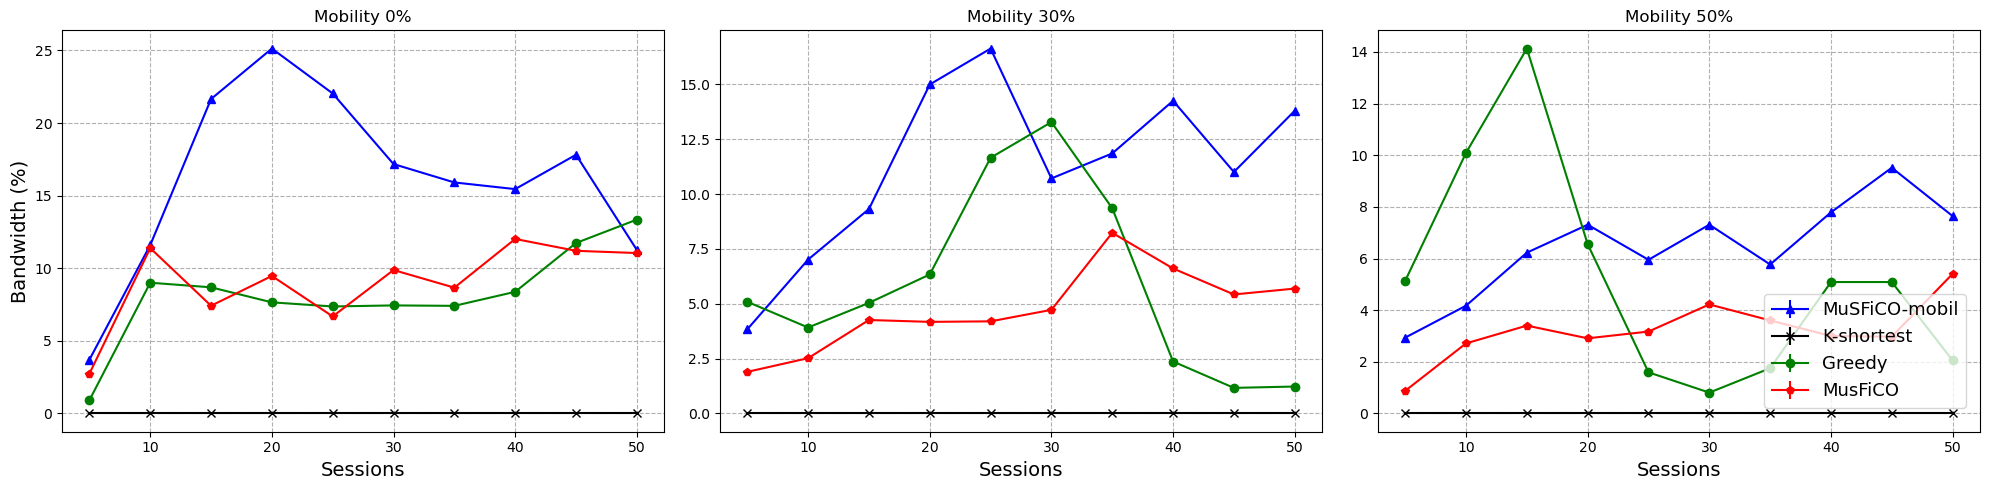

In [35]:
fig, axs = plt.subplots(ncols=3, figsize=(20, 5))

axs[0].errorbar(
    flows,
    mean_arr_dp_on_0_resource * PERCENTAGE,
    yerr=sem_arr_dp_on_0_resource,
    c="blue",
    marker="^",
    label="MuSFiCO-mobil",
)
axs[0].errorbar(
    flows,
    mean_arr_k_on_0_resource * PERCENTAGE,
    yerr=sem_arr_k_on_0_resource,
    c="black",
    marker="x",
    label="K-shortest",
)
axs[0].errorbar(
    flows,
    mean_arr_g_on_0_resource * PERCENTAGE,
    yerr=sem_arr_g_on_0_resource,
    c="green",
    marker="o",
    label="Greedy",
)
axs[0].errorbar(
    flows,
    mean_arr_dpnew_on_0_resource * PERCENTAGE,
    yerr=sem_arr_dpnew_on_0_resource,
    c="red",
    marker="p",
    label="MusFiCO",
)
axs[0].set_title("Mobility 0%")
axs[0].set_xlabel("Sessions")
axs[0].set_ylabel(f"{parameter_name}")
# axs[0].set_ylim([0, 10])
axs[0].grid(True, axis="both", linestyle="dashed")

axs[1].errorbar(
    flows,
    mean_arr_dp_on_30_resource * PERCENTAGE,
    yerr=sem_arr_dp_on_30_resource,
    c="blue",
    marker="^",
)
axs[1].errorbar(
    flows,
    mean_arr_k_on_30_resource * PERCENTAGE,
    yerr=sem_arr_k_on_30_resource,
    c="black",
    marker="x",
)
axs[1].errorbar(
    flows,
    mean_arr_g_on_30_resource * PERCENTAGE,
    yerr=sem_arr_g_on_30_resource,
    c="green",
    marker="o",
)
axs[1].errorbar(
    flows,
    mean_arr_dpnew_on_30_resource * PERCENTAGE,
    yerr=sem_arr_dpnew_on_30_resource,
    c="red",
    marker="p",
)
axs[1].set_title("Mobility 30%")
# axs[1].set_ylim([0, 10])
axs[1].set_xlabel("Sessions")
axs[1].grid(True, axis="both", linestyle="dashed")

axs[2].errorbar(
    flows,
    mean_arr_dp_on_50_resource * PERCENTAGE,
    yerr=sem_arr_dp_on_50_resource,
    c="blue",
    marker="^",
)
axs[2].errorbar(
    flows,
    mean_arr_k_on_50_resource * PERCENTAGE,
    yerr=sem_arr_k_on_50_resource,
    c="black",
    marker="x",
)
axs[2].errorbar(
    flows,
    mean_arr_g_on_50_resource * PERCENTAGE,
    yerr=sem_arr_g_on_50_resource,
    c="green",
    marker="o",
)
axs[2].errorbar(
    flows,
    mean_arr_dpnew_on_50_resource * PERCENTAGE,
    yerr=sem_arr_dpnew_on_50_resource,
    c="red",
    marker="p",
)
axs[2].set_title("Mobility 50%")
# axs[2].set_ylim([0, 10])
axs[2].set_xlabel("Sessions")
axs[2].grid(True, axis="both", linestyle="dashed")

ax_1 = fig.legend(bbox_to_anchor=(0.99, 0.42), fontsize=13)
fig.tight_layout()
# fig.savefig(f'figures/plot_{parameter}.png', bbox_extra_artists=(ax_1, ), bbox_inches='tight')